# <center> Redes neuronales para el Procesamiento del Lenguaje Natural </center>  


# Práctica 3: Redes Recurrentes para el procesado del Lenguaje Natural
## Jesús Ferrándiz Alarcón

En esta práctica vamos a abordar un problema de Análisis de Sentimientos mediante el uso de Redes Neuronales Recurrentes.

<!--
 Copyright 2025 Keybotic SL
  All Rights Reserved 
  
  Unauthorized copying of this file, via any medium is strictly prohibited, 
  unless it was supplied under the terms of a license agreement or 
  nondisclosure agreement with Keybotic SL. In this case it may not be 
  copied or disclosed except in accordance with the terms of that agreement.
-->



# Imports

Comenzamos importando una serie de módulos que usaremos después.

In [1]:
# Librerias necesarias
# Matplotlib conf
import matplotlib.pyplot as plt
%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':40,
         'ytick.labelsize': 40
}
plt.rcParams.update(params)
# Seaborn conf
import seaborn as sns
sns.set(style='darkgrid')
sns.set_palette(sns.color_palette("Blues"))

import sys

#Procesado de datos
import pandas as pd
import numpy as np
import operator

#Modelos
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Carga del Dataset, introspección y procesado
Cargamos el dataset como en la práctica 1. Los datos tabulares en .csv se
leen y cargan en una estructura de pandas.

In [2]:
training_set = pd.read_csv('./Dataset_reviews/train_reviews.csv')
print(f"Training set shape: {training_set.shape},* columns: {training_set.columns.tolist()}")
test_set = pd.read_csv('./Dataset_reviews/test_reviews.csv')
print(f"Test set shape: {test_set.shape}, columns: {test_set.columns.tolist()}")

Training set shape: (8000, 3),* columns: ['id', 'review', 'sentiment']
Test set shape: (2000, 3), columns: ['id', 'review', 'sentiment']


In [3]:
# Inspeccionamos el aspecto del conjunto de entrenamiento
training_set.head(20)

,id,review,sentiment
0,17527,People tried to make me believe that the premi...,negative
1,24155,I have been wanting to see cut since the day i...,positive
2,21972,This movie is terrible. The suspense is spent ...,negative
3,4565,I hope she can keep acting and directing. She'...,positive
4,22098,I fell in love with this silent action drama. ...,positive
5,5138,Shame Shame Shame on UA/DW for what you do! <b...,negative
6,16932,It's not very often a movie can literally make...,positive
7,13181,I was very interested to see this movie when i...,positive
8,3299,It might not be the best movie of 2006 but it ...,positive
9,18982,I went to see the Omega Code with a group of o...,negative


Revisamos el balance de clases.

([0, 1], [Text(0, 0, 'positive'), Text(1, 0, 'negative')])

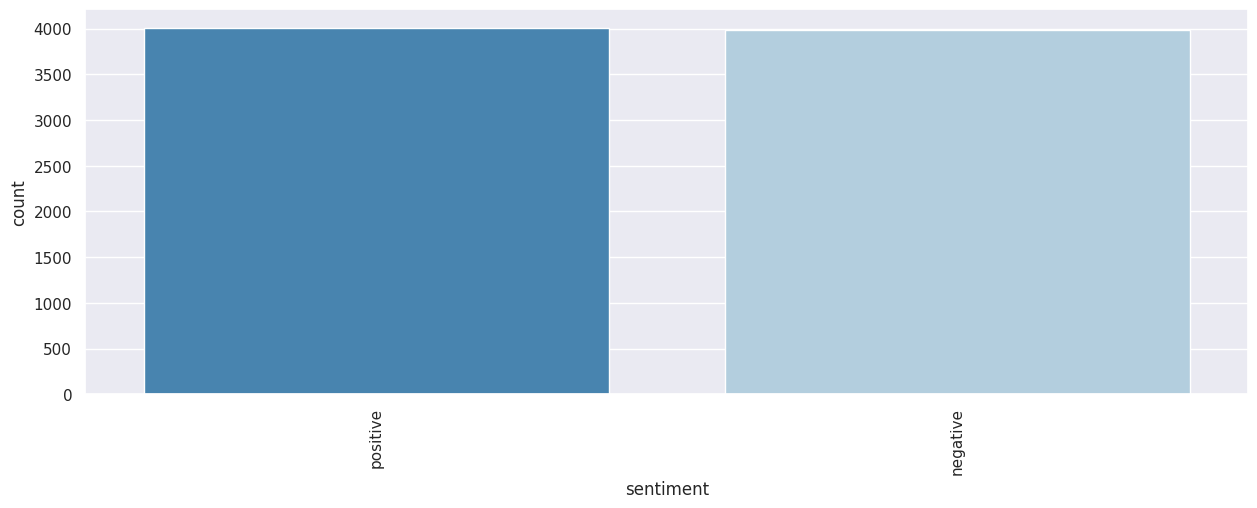

In [4]:
from collections import Counter
sns.countplot(data=training_set, x=training_set.sentiment, order=[x for x, count in sorted(Counter(training_set.sentiment).items(), key=lambda x: -x[1])], palette="Blues_r")
plt.xticks(rotation=90)

Hay un equilibrio entre el número de muestras de reseñas positivas y negativas.

A continuación procesamos las reseñas como en las prácticas anteriores:
- Eliminación de artefactos HTML
- Eliminar carácteres que no sean letras o números. Convertir a minúscula.
- Eliminar stop words del inglés (excepto ciertas negaciones)
- Aplicar lematización.

In [5]:
from bs4 import BeautifulSoup
import re

def strip_html_remove_links(text):
    soup = BeautifulSoup(text, "html.parser")
    for a in soup.find_all("a"):
        a.decompose()

    text = soup.get_text(separator=" ")

    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [6]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

import re
import contractions

nltk.download('stopwords')
nltk.download('wordnet')

negation_words = {"not", "no", "never", "nor"}

def process_text(raw_text, keep_numbers=True):

    text = contractions.fix(raw_text)

    text = strip_html_remove_links(text)

    text = text.lower()

    pattern = r"[^a-z0-9 ]" if keep_numbers else r"[^a-z ]"
    text = re.sub(pattern, " ", text)

    words = text.split()

    stop_words = set(stopwords.words("english")) - negation_words
    words = [w for w in words if w not in stop_words]

    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/jesus.ferrandiz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/jesus.ferrandiz/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [7]:
dataset = pd.concat([training_set, test_set])
dataset.shape
dataset.columns

Index(['id', 'review', 'sentiment'], dtype='object')

In [8]:
from tqdm import tqdm
tqdm.pandas()

dataset['processed_review'] = dataset['review'].progress_apply(lambda x: process_text(x))

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:06<00:00, 1527.78it/s]


In [9]:
X_train = dataset[0:len(training_set)][["id", "processed_review"]]
y_train = dataset[0:len(training_set)][["sentiment"]]

X_test = dataset[len(training_set):len(dataset)][["id", "processed_review"]]
y_test = dataset[len(training_set):len(dataset)][["sentiment"]]

Codificamos las etiquetas del string 'positive', 'negative' a un
vector plano de 0's y 1's.
Donde 0 -> negative, 1 -> positive

In [10]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
print(f"Values before encoding: {y_train.sentiment.values}")
le.fit(y_train.sentiment.values)
target_labels = le.classes_
encoded_y_train = le.transform(y_train.sentiment.values)
print(f"Labels after encoding: {encoded_y_train}")

print(f"Target labels: {target_labels}")

encoded_y_test = le.transform(y_test.sentiment.values)


Values before encoding: ['negative' 'positive' 'negative' ... 'negative' 'negative' 'negative']
Labels after encoding: [0 1 0 ... 0 0 0]
Target labels: ['negative' 'positive']


In [11]:
Y_train = encoded_y_train  # Shape: (n_samples,)
Y_test = le.transform(y_test.values)

print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

print(Y_train[0:10])

Y_train shape: (8000,)
Y_test shape: (2000,)
[0 1 0 1 1 0 1 1 1 0]


# Entrenamiento de Redes Neuronales

Igual que en la práctica sobre Redes Convolucionales, he decidido implementar esta práctica con el framework PyTorch.

## Utilidades

A continuación voy a definir una serie de utilidades para trabajar con modelos de PyTorch.

In [12]:
# Importamos capas densas, capas de embeddings y capas para el aplanaEl hecho de que de una manera se pueda explicar el resultado del modelo ayuda do de dimensiones
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Defino una función para crear dos gráficos:
- Train y validation loss.
- Train y validation accuracy.

Estos nos ayudarán a ver si hay sobreajuste a los datos de entrenamiento y si el entrenamiento es estable.

In [13]:
# Con esta función podremos ver cómo evoluciona el entrenamiento y la validación de los modelos.

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Clase similar a la estructura que se obtiene al entrenar los modelos en tf.keras
class History:
    def __init__(self):
        self.history = {
            'loss': [],
            'acc': [],
            'val_loss': [],
            'val_acc': []
        }

def plot_history(history, metric='acc'):
    acc = history.history[metric]
    val_acc = history.history[f'val_{metric}']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

El siguiente método lo utilizaré para mostrar en un mismo gráfico diferentes históricos
en validación para comparar entrenamientos.

In [14]:
def plot_histories(histories, names, metric='acc'):
    colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    for history, name, color in zip(histories, names, colors):
        epochs = range(1, len(history.history[metric]) + 1)
        plt.plot(epochs, history.history[metric], '--', color=color, alpha=0.5)
        plt.plot(epochs, history.history[f'val_{metric}'], '-', color=color, label=name)
    plt.title(f'Validation {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    for history, name, color in zip(histories, names, colors):
        epochs = range(1, len(history.history['loss']) + 1)
        plt.plot(epochs, history.history['loss'], '--', color=color, alpha=0.5)
        plt.plot(epochs, history.history['val_loss'], '-', color=color, label=name)
    plt.title('Validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

Este otro método lo utilizaremos para mostrar la matriz de confusión:

In [15]:
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues,
                          fmt=None):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if fmt is None:
        fmt = '.2f' if normalize else 'd'

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

Con este método veremos el número de parámetros de un modelo.
Utilizaremos este método para comparar el tamaño de cada modelo que entrenaremos.

In [16]:
def print_model_params(model):

    total_params = 0
    trainable_params = 0

    print(f"{'Layer':<40} {'Parameters':<15} {'Shape':<20}")
    print("-" * 80)

    for name, param in model.named_parameters():
        num_params = param.numel()
        total_params += num_params
        if param.requires_grad:
            trainable_params += num_params

        print(f"Name: {name}, num params: {num_params}, shape: {str(list(param.shape))}")

    print(f"Total Parameters: {total_params}")
    print(f"Trainable Parameters: {trainable_params}")
    print(f"Non-trainable Parameters: {(total_params - trainable_params)}")

    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    size_mb = (param_size + buffer_size) / 1024**2

    print(f"Model Size: {size_mb:.2f} MB")

Defino el siguiente método para entrenar y evaluar en datos de validación un modelo de Pytorch.

Permito pasar una función **collate_fn** a los dataloaders que nos permitirá implementar después
un batch de tamaño de secuencia dinámica.

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
from tqdm import tqdm

def train_and_evaluate(model, train_dataset, valid_dataset, criterion, optimizer, batch_size=32, num_epochs=10, 
                       device='cuda' if torch.cuda.is_available() else 'cpu', scheduler=None, patience=None, collate_fn=None, verbose=True, pass_lengths=False):


    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    model = model.to(device)
    history = History()

    # Guardamos ls mejor métrica de pérdidas en validación para implementar "early stopping".
    best_val_loss = float('inf')
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_preds = []
        train_labels = []
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):

            if len(batch) == 3:
                batch_X, batch_y, lengths = batch
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
                lengths = lengths.to(device)

                if pass_lengths:
                    outputs = model(batch_X, lengths)
                else:
                    outputs = model(batch_X)
            else:
                batch_X, batch_y = batch
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
                outputs = model(batch_X)

            optimizer.zero_grad()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            # En esta práctica tendremos 2 neuronas de salida
            # y la clase escogida es aquella cuya neurona asociada de salida
            # tenga la activación mayor.
            # Usamos la loss CrossEntropyLoss que se aplica directamente a los logits, ver:
            # https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
            _, predicted = torch.max(outputs, 1)
            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(batch_y.cpu().numpy())

        if scheduler is not None:
            scheduler.step()

        # Calculamos las métricas de entrenamiento
        train_loss /= len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)

        # Validación:
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_labels = []
        with torch.no_grad():
            for batch in val_loader:

                if len(batch) == 3:
                    batch_X, batch_y, lengths = batch
                    batch_X = batch_X.to(device)
                    batch_y = batch_y.to(device)
                    lengths = lengths.to(device)

                    if pass_lengths:
                        outputs = model(batch_X, lengths)
                    else:
                        outputs = model(batch_X)
                else:
                    batch_X, batch_y = batch
                    batch_X = batch_X.to(device)
                    batch_y = batch_y.to(device)
                    outputs = model(batch_X)

                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(batch_y.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = accuracy_score(val_labels, val_preds)

        history.history['loss'].append(train_loss)
        history.history['acc'].append(train_acc)
        history.history['val_loss'].append(val_loss)
        history.history['val_acc'].append(val_acc)

        if verbose:
            print(f'Epoch {epoch+1}/{num_epochs}:')
            print(f'Train Loss: {train_loss}, Train Acc: {train_acc}')
            print(f'Val Loss: {val_loss}, Val Acc: {val_acc}')
            print()

        # Early stopping
        if patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = model.state_dict().copy()
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    print(f'Early stopping at epoch {epoch+1} (no improvement in {patience} epochs)')
                    model.load_state_dict(best_model_state)
                    break

    return model, history

Defino el siguiente método para generar predicciones en el dataset de evaluación.

In [18]:
import scipy.sparse as sp

def predict_pytorch(model, X_tensor, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model = model.to(device)
    model.eval()

    X_tensor = X_tensor.to(device)

    # Predict
    with torch.no_grad():
        outputs = model(X_tensor)
        _, predicted = torch.max(outputs, 1)

    return predicted.cpu().numpy()

Este método recibe las precicciones en test, las etiquetas y genera las métricas de test.

In [19]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, f1_score, recall_score
from sklearn.metrics import confusion_matrix

from numpy.typing import ArrayLike
from typing import Dict, Any, List


def compute_and_show_metrics(y_test: ArrayLike, y_pred: ArrayLike, target_labels: List['str']) -> Dict[str, Any]:

    print(f"Tamaño de y_test (etiquetas): {y_test.shape}")
    print(f"Tamaño de y_pred (predicciones): {y_pred.shape}")

    print("Classification report: ")
    print(classification_report(y_test, y_pred, target_names=target_labels))

    cm = confusion_matrix(y_test, y_pred, labels=target_labels, normalize='true')
    print("Confusion matrix: ")
    plot_confusion_matrix(cm, classes=target_labels, fmt='.3f')

    accuracy = accuracy_score(y_test, y_pred)

    metrics = {
        "accuracy": accuracy,
    }

    print("Overall metrics:")
    print(metrics)

    return metrics
    

## Arquitectura propuesta

Las redes neuronales recurrentes procesan secuencias ordenadas. En esta práctica entonces, no vamos a utilizar representaciones vectoriales basadas
en BoW, TF, TF-IDF porque estas representaciones pierden la noción del orden de la secuencia de texto de entrada.

Con experimentos en la práctica anterior, ya vimos que los modelos convolucionales 1D que procesan features TF/TF-IDF no extraian features útiles para clasificar.

En esta práctica, en todos los experimentos vamos a utilizar Word Embeddings para que se asocie a cada palabra un vector
denso y transformar la secuencia de entrada como secuencia de tokens a una secuencia de vectores densos que sí tiene
en cuenta el orden.

Como las secuencias de entrada de los modelos pueden ser de tamaño variable, utilizaremos mecanismos de Pooling para colapsar esta dimensión a un valor y que
los MLP de salida puedan trabajar con una entrada de tamaño fijo para la clasificación.

## Procesado del dataset a Word Embeddings

In [20]:
import torch
import numpy as np

# 1. Construimos el vocabulario a partir de los datos preprocesados
word_counts = {}
for text in X_train['processed_review']:
    for word in text.split():
        word_counts[word] = word_counts.get(word, 0) + 1

# A cada palabra del vocabulario le asignamos un índice
sorted_words = sorted(word_counts.items(), key=lambda x: -x[1])
word_index = {word: idx + 2 for idx, (word, _) in enumerate(sorted_words)}
word_index['<OOV>'] = 1

vocab_size = len(word_index) + 1

# 2. Convertimos los textos a secuencias de índices (enteros)
def texts_to_sequences(texts, word_index):
    sequences = []
    for text in texts:
        # Si una palabra no está en el vocabulario, se pone un out of vocabulary token
        seq = [word_index.get(word, word_index['<OOV>']) for word in text.split()]
        sequences.append(seq)
    return sequences

train_sequences = texts_to_sequences(X_train['processed_review'], word_index)
test_sequences = texts_to_sequences(X_test['processed_review'], word_index)

index_to_word = {idx: word for word, idx in word_index.items()}

In [21]:
print(f"Vocab size: {vocab_size}")

Vocab size: 41882


El diccionario index_to_word contiene un mapping entre los índices de los tokens y su string asociado.

In [22]:
for idx in train_sequences[0]:
    print(f"{idx}: {index_to_word.get(idx, '<???>')}")

21: people
625: tried
15: make
175: believe
683: premise
17182: rubbishy
2382: supernatural
98: horror
487: thriller
1423: inspired
626: actual
131: last
267: word
3037: spoken
2519: authentic
1187: serial
277: killer
459: whose
250: name
763: escape
146: moment
1729: whilst
6306: awaiting
2413: execution
4400: electric
2451: chair
3939: claimed
1022: soul
8: would
519: return
31: life
1528: continue
32: go
42: never
168: ending
334: murder
5233: spree
2: not
397: highly
107: original
162: idea
8887: revolve
98: horror
4: film
28: way
241: low
245: budget
2292: turkey
17183: implemented
2669: exact
1000: basic
683: premise
6: like
166: house
244: 3
6307: shocker
874: ghost
1118: machine
456: anyway
27: first
380: power
1637: k
20410: pentagram
2: not
231: completely
298: terrible
443: effort
125: script
1805: overly
17184: reverts
642: clich
353: lack
2016: genuine
1942: thrill
4: film
142: start
706: okay
2711: albeit
4269: mundane
1187: serial
277: killer
308: flick
5829: obsessive
5

Ahora que tenemos las secuencias tokenizadas. Quiero ver la distribución de longitudes de secuencia. Entender
esta distribución nos ayudará a tomar decisiones sobre los modelos.

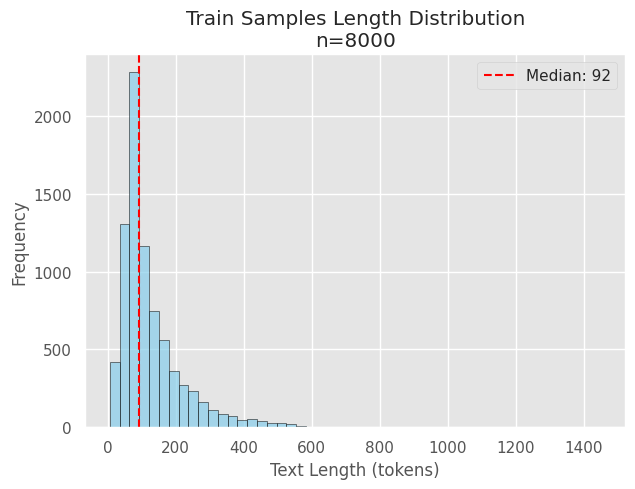

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate lengths (in tokens)
train_lengths = [len(text) for text in train_sequences]

# Create the plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Text Length (tokens)')
plt.ylabel('Frequency')
plt.title(f'Train Samples Length Distribution\nn={len(train_lengths)}')
plt.axvline(np.median(train_lengths), color='red', linestyle='--', label=f'Median: {np.median(train_lengths):.0f}')
plt.legend()

plt.tight_layout()
plt.show()

Tenemos una longitud mediana de 92 tokens.
Para construir batches como hemos hecho en anteriores tareas necesitamos que todas las secuencias tengan la misma longitud. Por ahora vamos a seguir con una
estrategia de procesar secuencias de longitud fija (esto ya no tiene por qué ser así en RNNs). Defino una longitud de secuencia máxima de 300 tokens y
a las secuencias más cortas se les añadirán tokens de padding y las más largas se truncarán.

In [24]:
MAX_LENGTH=300

def pad_sequences_torch(sequences, maxlen, padding_value=0):
    result = np.full((len(sequences), maxlen), padding_value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        trunc = seq[:maxlen]
        result[i, :len(trunc)] = trunc
    return torch.tensor(result, dtype=torch.long)

train_padded = pad_sequences_torch(train_sequences, MAX_LENGTH)
test_padded = pad_sequences_torch(test_sequences, MAX_LENGTH)

print(f"Train shape: {train_padded.shape}")
print(f"Test shape: {test_padded.shape}")
print(f"Vocabulary size: {vocab_size}")

# Example: First sample
print(f"\nOriginal text: {X_train['processed_review'].iloc[0]}")
print(f"Sequence: {train_sequences[0]}")
print(f"Padded: {train_padded[0]}")

Train shape: torch.Size([8000, 300])
Test shape: torch.Size([2000, 300])
Vocabulary size: 41882

Original text: people tried make believe premise rubbishy supernatural horror thriller inspired actual last word spoken authentic serial killer whose name escape moment whilst awaiting execution electric chair claimed soul would return life continue go never ending murder spree not highly original idea revolve horror film way low budget turkey implemented exact basic premise like house 3 shocker ghost machine anyway first power k pentagram not completely terrible effort script overly reverts clich lack genuine thrill film start okay albeit mundane serial killer flick obsessive cop hero lou diamond philip pursues maniac carves bloody pentagram chest victim receives unexpected help spiritual medium played gorgeous underrated tracy griffith lead killer also begs not execute would result even bigger catastrophe thanks tess helpful hint detective logan quickly capture killer celebrates death pen

Creamos ahora datasets y dataloaders de pytorch con el dataset convertido a tokens/índices y con longitud fija de todas las secuencias.

In [25]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# Split train into train/valid
X_train, X_valid, y_train, y_valid = train_test_split(
    train_padded,
    encoded_y_train,
    test_size=0.2,
    random_state=42,
)

# Convert to PyTorch tensors (LongTensor for word indices!)
X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)

X_valid_tensor = torch.LongTensor(X_valid)
y_valid_tensor = torch.LongTensor(y_valid)

X_test_tensor = torch.LongTensor(test_padded)
y_test_tensor = torch.LongTensor(encoded_y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print(f"Train samples: {len(train_dataset)}")
print(f"Valid samples: {len(valid_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 6400
Valid samples: 1600
Test samples: 2000


# Longitud de secuencia de tamaño fijo

Vamos a empezar con todas las secuencias de entrenamiento, validación y test con un tamaño fijo de 300.
Como se ha mostrado anteriormente, se ha añadido un token de padding para que las secuencias más cortas alcancen 300 elementos.
Y se han truncado las secuencias más largas.

## ID=1 WE + MLP (Experimento de Control)

Quiero realizar un entrenamiento que no incluya redes neuronales recurrentes para validar una arquitectura ya utilizada en tareas anteriores con el procesamiento de datos hecho en esta práctica.

El siguiente modelo consiste en una capa de Embeddings, max pooling y un MLP para convertir las features al número de clases objetivo.
En este caso, voy a implementar los modelos con dos neuronas de salida y utilizar **CrossEntropyLoss**.

Durante inferencia, consideraremos la clase elegida como aquella que valor máximo tenga entre las dos neuronas de salida.

Para los tamaños de los tensores:
- B: Batch size
- S: Longitud de Secuencia
- E: Dimensión de Embeddings
- NC: Número de Clases

In [26]:
import torch
import torch.nn as nn

class EmbeddingMLPClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dims, num_classes, 
                 dropout=0.5):
        super(EmbeddingMLPClassifier, self).__init__()

        # Capa de embedding. Convierte la entrada a secuencias de vectores de embedding. Un vector por token.
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        layers = []
        input_dim = embedding_dim
        # Utilizamos un bloque de:
        # - MLP
        # - Activación ReLU
        # - Dropout para reducir overfitting
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, num_classes))        
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: [B, S]

        # Embedding
        embedded = self.embedding(x)  # [B, S, E]

        # Colapsamos la dimensión de la secuencia. Se pierde información
        # sobre el orden de las palabras
        # Aquí usamos avg pooling
        pooled, _ = embedded.max(dim=1)

        output = self.mlp(pooled)  # [B, NC]

        return output

In [27]:
print(np.unique(encoded_y_train))
print(np.unique(encoded_y_test))

[0 1]
[0 1]


Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 12564600, shape: [41882, 300]
Name: mlp.0.weight, num params: 38400, shape: [128, 300]
Name: mlp.0.bias, num params: 128, shape: [128]
Name: mlp.3.weight, num params: 8192, shape: [64, 128]
Name: mlp.3.bias, num params: 64, shape: [64]
Name: mlp.6.weight, num params: 128, shape: [2, 64]
Name: mlp.6.bias, num params: 2, shape: [2]
Total Parameters: 12611514
Trainable Parameters: 12611514
Non-trainable Parameters: 0
Model Size: 48.11 MB


Epoch 1/80: 100%|██████████| 200/200 [00:00<00:00, 420.37it/s]


Epoch 1/80:
Train Loss: 0.6970920121669769, Train Acc: 0.50703125
Val Loss: 0.6914129424095153, Val Acc: 0.508125



Epoch 2/80: 100%|██████████| 200/200 [00:00<00:00, 421.50it/s]


Epoch 2/80:
Train Loss: 0.6919262543320656, Train Acc: 0.514375
Val Loss: 0.6869762134552002, Val Acc: 0.585625



...

Epoch 47/80:
Train Loss: 0.25050672952085734, Train Acc: 0.9009375
Val Loss: 0.5488838040828705, Val Acc: 0.77625



Epoch 48/80: 100%|██████████| 200/200 [00:00<00:00, 420.60it/s]


Epoch 48/80:
Train Loss: 0.2396247813105583, Train Acc: 0.905625
Val Loss: 0.5262534940242767, Val Acc: 0.779375



Epoch 49/80: 100%|██████████| 200/200 [00:00<00:00, 423.70it/s]


Epoch 49/80:
Train Loss: 0.23422787457704544, Train Acc: 0.91078125
Val Loss: 0.5488954824209213, Val Acc: 0.78375

Early stopping at epoch 49 (no improvement in 10 epochs)


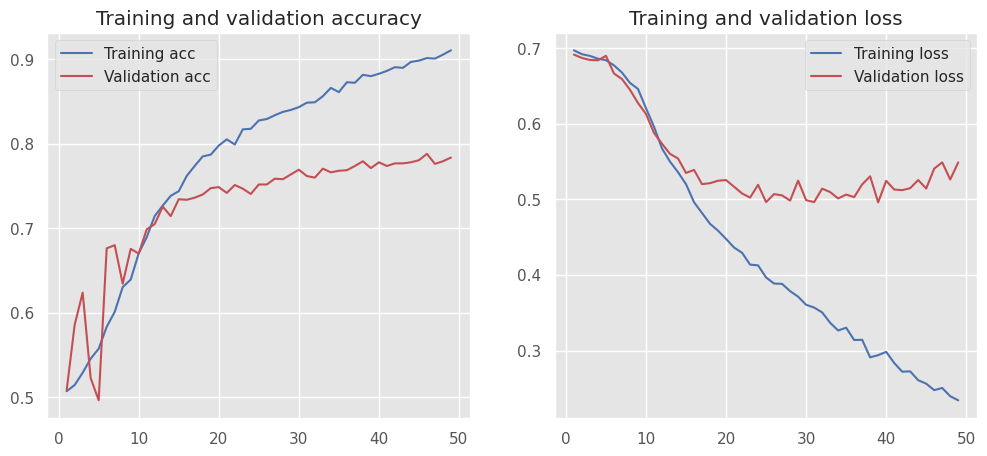

In [30]:
#Número de épocas
epochs = 80
#Dimensión de la capa de embeddings
emb_dim = 50

num_classes = 2
model = EmbeddingMLPClassifier(vocab_size=vocab_size, embedding_dim=300, hidden_dims=[128, 64], num_classes=num_classes, dropout=0.3)

print_model_params(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.001)

model, history = train_and_evaluate(
    model, 
    train_dataset, 
    valid_dataset,
    criterion,
    optimizer,
    num_epochs=epochs,
    batch_size=32,
    patience=10
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.80      0.75      0.78      1025
    positive       0.75      0.81      0.78       975

    accuracy                           0.78      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.78      0.78      0.78      2000

Confusion matrix: 
Confusion matrix, without normalization


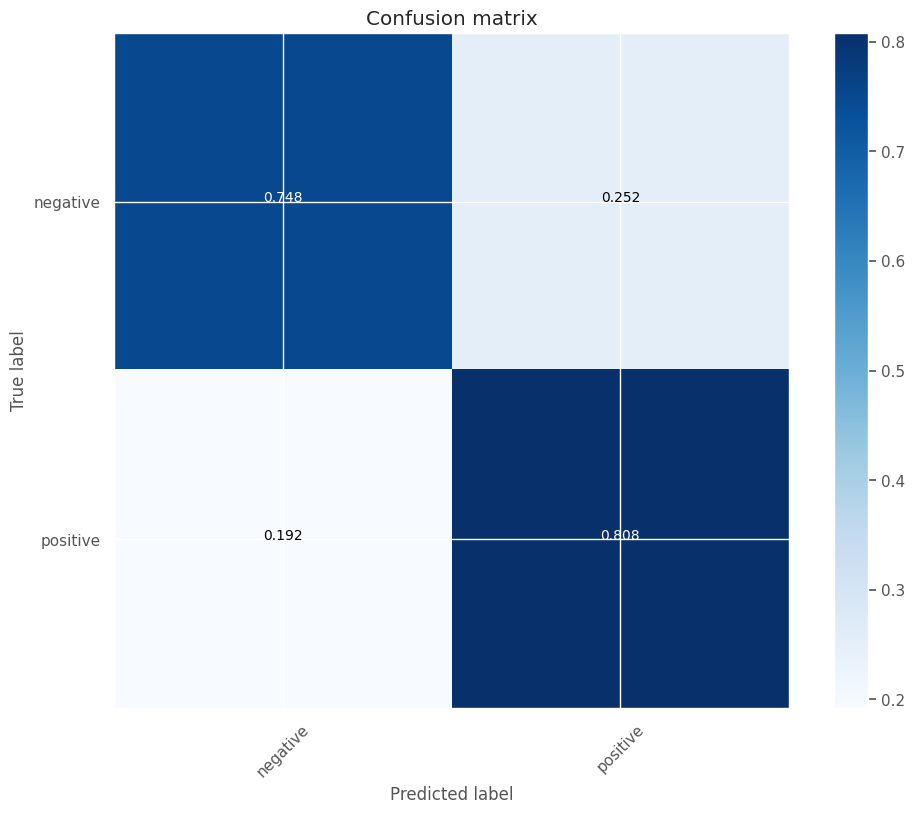

Overall metrics:
{'accuracy': 0.7775}


{'accuracy': 0.7775}

In [32]:
y_pred = predict_pytorch(model, X_test_tensor)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

Hemos obtenido mejores resultados en las prácticas anteriores que un 77.75% de accuracy en evaluación, pero utilizamos este modelo solo como experimento de control.
En los siguientes experimentos, nos enfocaremos en Redes Neuronales Recurrentes.

## ID=2 WE + RNN

En este entrenamiento vamos a utilizar una Red Recurrente estándar.
Tenemos una capa de Embeddings, después la red recurrente.

En los tamaños:
- H: Hidden Dim
- NL: Num Layers

Conectaremos el último estado oculto de la última capa de la red recurrente con la entrada
del MLP de salida que nos transformará el estado oculto en las 2 neuronas de salida para la clasificación.

In [51]:
import torch
import torch.nn as nn

class EmbeddingRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 num_layers=1, dropout=0.5):
        super(EmbeddingRNNClassifier, self).__init__()

        # Capa de embedding. Convierte tokens a vectores.
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # RNN: procesa la secuencia paso a paso, manteniendo un estado oculto
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        # Capa final de clasificación
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x shape: [B, S]

        # Embedding
        embedded = self.embedding(x)  # [B, S, E]

        # RNN procesa toda la secuencia
        # output: [B, S, H] (salida en cada paso)
        # hidden: [NL, B, H] (último estado oculto)
        output, hidden = self.rnn(embedded)

        # print(f"Hidden shape: {hidden.shape}")

        # Tomamos el último estado oculto de la última capa
        # Contiene información de toda la secuencia (a diferencia del MLP)
        last_hidden = hidden[-1]  # [B, H]

        # print(f"Last hidden shape: {last_hidden.shape}")

        last_hidden = self.dropout(last_hidden)

        # Clasificación
        out = self.fc(last_hidden)  # [batch_size, num_classes]
        return out

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 4188200, shape: [41882, 100]
Name: rnn.weight_ih_l0, num params: 12800, shape: [128, 100]
Name: rnn.weight_hh_l0, num params: 16384, shape: [128, 128]
Name: rnn.bias_ih_l0, num params: 128, shape: [128]
Name: rnn.bias_hh_l0, num params: 128, shape: [128]
Name: fc.weight, num params: 256, shape: [2, 128]
Name: fc.bias, num params: 2, shape: [2]
Total Parameters: 4217898
Trainable Parameters: 4217898
Non-trainable Parameters: 0
Model Size: 16.09 MB


Epoch 1/80:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 200/200 [00:00<00:00, 433.20it/s]


Epoch 1/80:
Train Loss: 0.6959764364361763, Train Acc: 0.5103125
Val Loss: 0.6929721856117248, Val Acc: 0.496875



Epoch 2/80: 100%|██████████| 200/200 [00:00<00:00, 417.01it/s]


...

Epoch 33/80:
Train Loss: 0.6967986384034157, Train Acc: 0.49875
Val Loss: 0.6937070059776306, Val Acc: 0.50125



Epoch 34/80: 100%|██████████| 200/200 [00:00<00:00, 447.12it/s]


Epoch 34/80:
Train Loss: 0.6964722207188606, Train Acc: 0.49828125
Val Loss: 0.6964307713508606, Val Acc: 0.499375



Epoch 35/80: 100%|██████████| 200/200 [00:00<00:00, 445.72it/s]


Epoch 35/80:
Train Loss: 0.6960219976305961, Train Acc: 0.4978125
Val Loss: 0.6930819571018219, Val Acc: 0.505

Early stopping at epoch 35 (no improvement in 20 epochs)


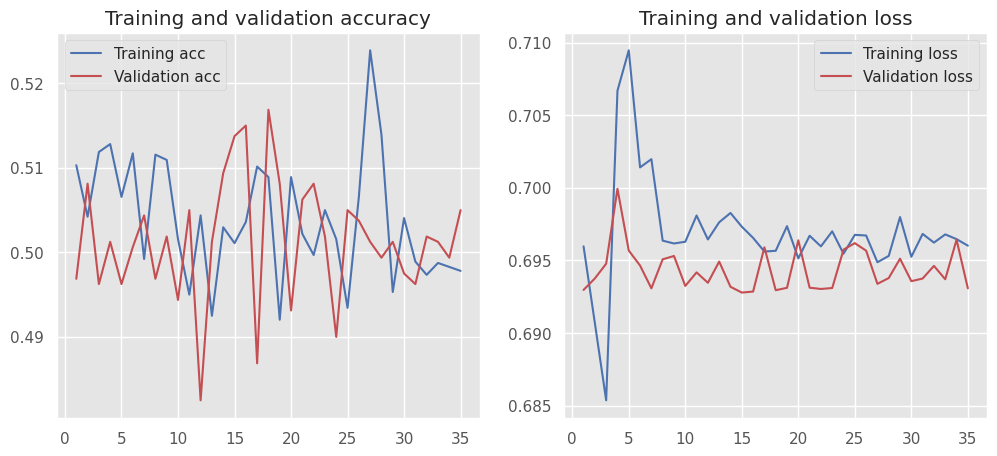

In [72]:
num_classes = 2
model = EmbeddingRNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=100,
    hidden_dim=128,
    num_classes=num_classes,
    num_layers=1,
    dropout=0.5
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0001)

print_model_params(model)

model, history = train_and_evaluate(
    model, 
    train_dataset, 
    valid_dataset,
    criterion,
    optimizer,
    num_epochs=epochs,
    patience=20,
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.50      0.33      0.40      1025
    positive       0.48      0.65      0.55       975

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.48      2000
weighted avg       0.49      0.49      0.47      2000

Confusion matrix: 
Confusion matrix, without normalization


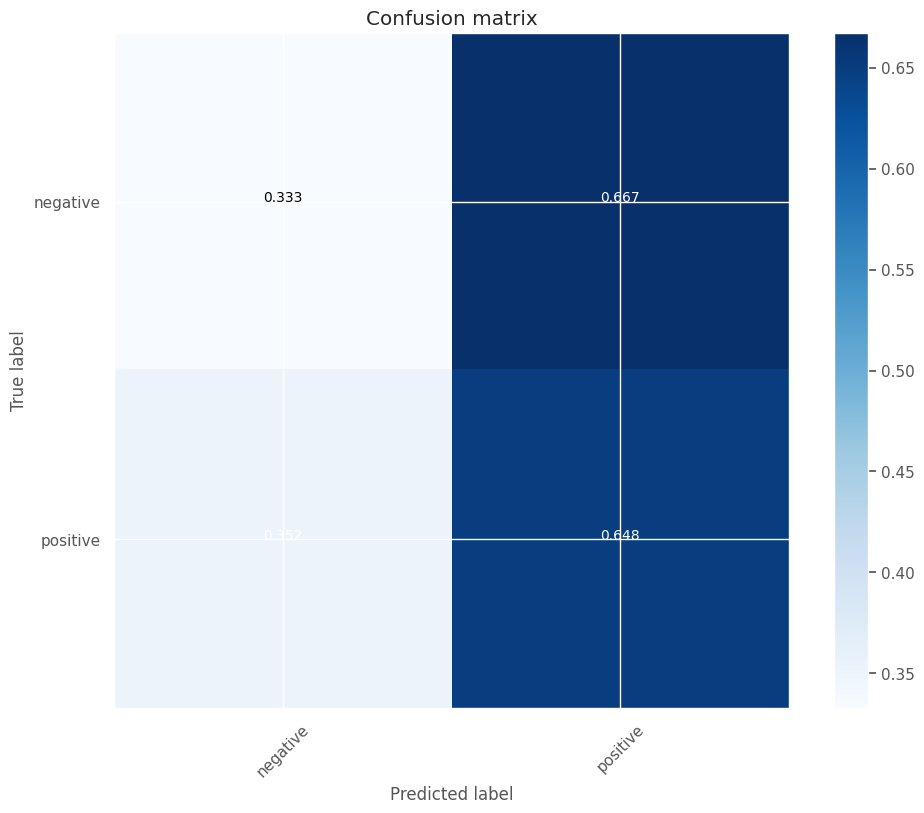

Overall metrics:
{'accuracy': 0.4865}


{'accuracy': 0.4865}

In [73]:
y_pred = predict_pytorch(model, X_test_tensor)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

Este modelo basado en una simple RNN no aprende correctamente en los datos que tenemos. Después de 20 epochs, training loss no disminuye lo suficiente. Es posible que al tratar con
secuencias relativamente largas (300) estemos sufriendo el problema del desvanecimiento del gradiente.

## ID=3 WE + RNN; Longitud de Secuencia = 100

Es posible que una RNN estandar no pueda procesar secuencias de longitud 300. Voy a disminuir la longitud de máxima secuencia de 300 a 100.

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 4188200, shape: [41882, 100]
Name: rnn.weight_ih_l0, num params: 12800, shape: [128, 100]
Name: rnn.weight_hh_l0, num params: 16384, shape: [128, 128]
Name: rnn.bias_ih_l0, num params: 128, shape: [128]
Name: rnn.bias_hh_l0, num params: 128, shape: [128]
Name: fc.weight, num params: 256, shape: [2, 128]
Name: fc.bias, num params: 2, shape: [2]
Total Parameters: 4217898
Trainable Parameters: 4217898
Non-trainable Parameters: 0
Model Size: 16.09 MB


Epoch 1/80:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 200/200 [00:00<00:00, 512.55it/s]


Epoch 1/80:
Train Loss: 0.7084627291560173, Train Acc: 0.49984375
Val Loss: 0.6979896903038025, Val Acc: 0.48125



Epoch 2/80: 100%|██████████| 200/200 [00:00<00:00, 498.64it/s]


...

Epoch 20/80:
Train Loss: 0.333248405456543, Train Acc: 0.7878125
Val Loss: 1.3337927103042602, Val Acc: 0.534375



Epoch 21/80: 100%|██████████| 200/200 [00:00<00:00, 521.11it/s]


Epoch 21/80:
Train Loss: 0.315263070166111, Train Acc: 0.82265625
Val Loss: 1.263796808719635, Val Acc: 0.555



Epoch 22/80: 100%|██████████| 200/200 [00:00<00:00, 524.54it/s]


Epoch 22/80:
Train Loss: 0.3335336831584573, Train Acc: 0.8234375
Val Loss: 1.4054626441001892, Val Acc: 0.51125

Early stopping at epoch 22 (no improvement in 20 epochs)


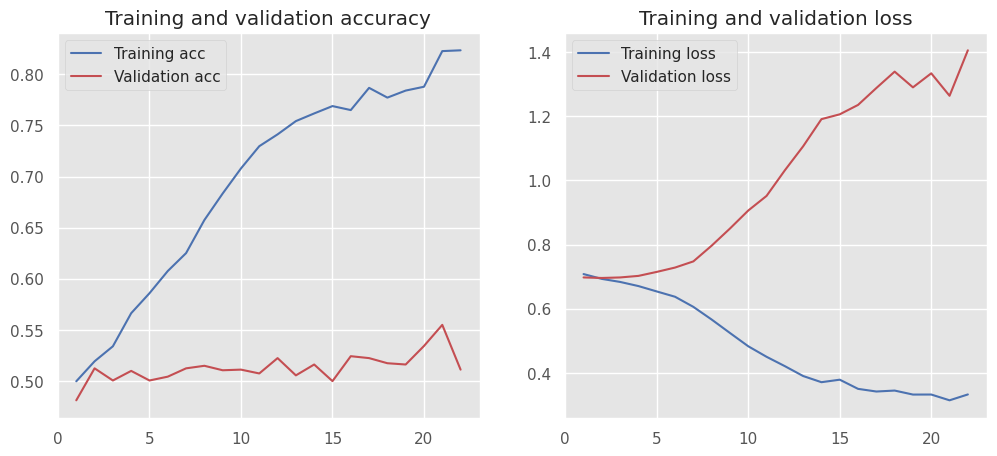

In [ ]:
def make_truncate_collate(max_len):
    def collate_fn(batch):
        inputs, labels = zip(*batch)
        
        # Truncate sequences to max_len
        inputs = [x[:max_len] for x in inputs]
        
        inputs = torch.stack(inputs)
        labels = torch.stack(labels)
        
        return inputs, labels
    return collate_fn

num_classes = 2
model = EmbeddingRNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=100,
    hidden_dim=128,
    num_classes=num_classes,
    num_layers=1,
    dropout=0.5
)

print_model_params(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0001)

model, history = train_and_evaluate(
    model, 
    train_dataset, 
    valid_dataset,
    criterion,
    optimizer,
    num_epochs=epochs,
    patience=20,
    collate_fn=make_truncate_collate(max_len=100)
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.52      0.97      0.68      1025
    positive       0.61      0.05      0.09       975

    accuracy                           0.52      2000
   macro avg       0.57      0.51      0.38      2000
weighted avg       0.56      0.52      0.39      2000

Confusion matrix: 
Confusion matrix, without normalization


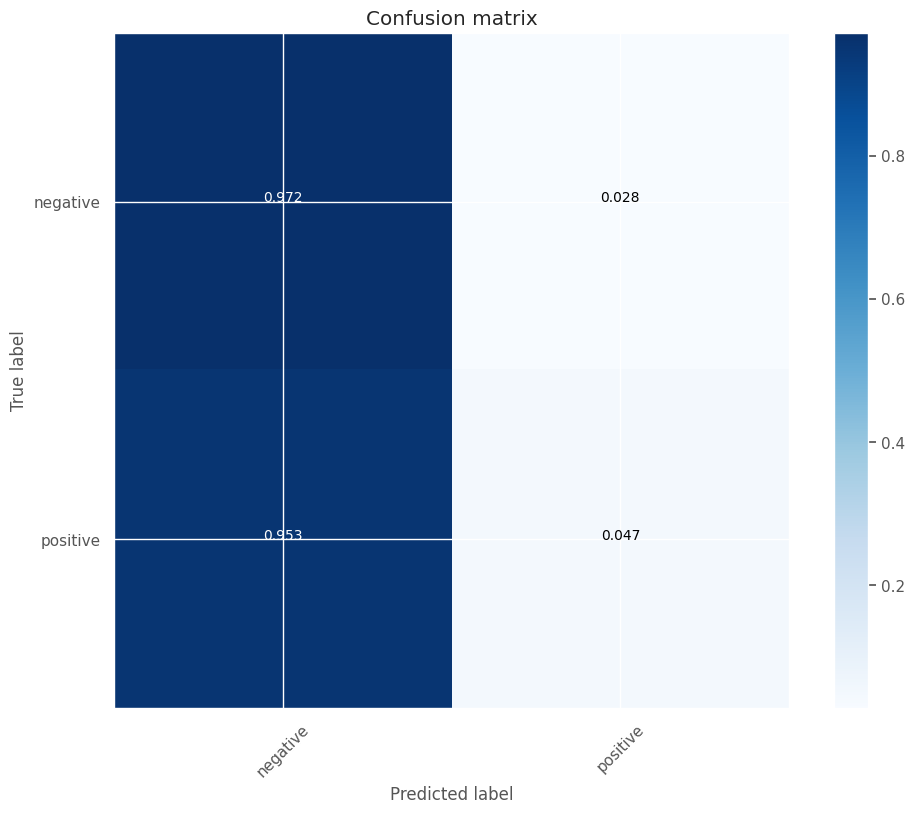

Overall metrics:
{'accuracy': 0.521}


{'accuracy': 0.521}

In [75]:
y_pred = predict_pytorch(model, X_test_tensor)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

Ahora al menos train loss ha disminuido más, y train accuracy sube más. Pero en validación no sucede esto. El modelo está haciendo overfitting a los datos de entrenamiento.
Está aprendiendo del ruido de entrenamiento. A continuación vamos a empezar a probar con arquitecturas recurrentes más complejas que evitan problemas como el desvanecimiento del gradiente y cuyo entrenamiento debería ser más estable.

Hay que tener en cuenta que al truncar las secuencias, estamos también perdiendo información.

## ID=4 WE + LSTM Unidireccional

A continuación tenemos un modelo con una capa de Embeddings, después una LSTM y finalmente una MLP.
Preparo el modelo para poder elegir el número de capas LSTM y si es unidireccional o bidireccional.

En este modelo haremos max pooling para colapsar la dimensión de la secuencia y tener un tamaño fijo en la entrada del MLP.

LSTM en pytorch: https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html

In [33]:
import torch
import torch.nn as nn

class EmbeddingLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dims, num_classes,
                 lstm_hidden_dim=128, lstm_layers=1, bidirectional=True, dropout=0.5):
        super(EmbeddingLSTMClassifier, self).__init__()

        # Capa de embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # LSTM: procesa la secuencia y captura dependencias temporales
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout
        )

        # Si es bidireccional, el output tiene el doble de dimensiones
        # Las features de derecha a izquierda y de izquierda a derecha de la secuencia.
        lstm_output_dim = lstm_hidden_dim * 2 if bidirectional else lstm_hidden_dim

        # MLP
        layers = []
        input_dim = lstm_output_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        embedded = self.embedding(x)  # [B, S, E]

        # Según la documentación https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html
        # El forward de la LSTM devuelve:
        # lstm_out, (h_n, c_n)
        # donde lstm_out es un tensor que contiene los features de salida
        # de la última capa de la LSTM para cada t (paso de la secuencia).
        lstm_out, _ = self.lstm(embedded)  # [B, S, lstm_output_dim]

        # Para cada feature del LSTM, se tomará el valor máximo
        # a lo largo de los pasos "temporales". Esto hace que 
        # podamos tener después una capa MLP (de tamaño fijo) y
        # poder tener aún así secuencias de entrada de
        # diferente longitud. 
        pool, _ = lstm_out.max(dim=1)  # [B, lstm_output_dim]
        output = self.mlp(pool)
        return output

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 8376400, shape: [41882, 200]
Name: lstm.weight_ih_l0, num params: 102400, shape: [512, 200]
Name: lstm.weight_hh_l0, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0, num params: 512, shape: [512]
Name: lstm.bias_hh_l0, num params: 512, shape: [512]
Name: lstm.weight_ih_l1, num params: 65536, shape: [512, 128]
Name: lstm.weight_hh_l1, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l1, num params: 512, shape: [512]
Name: lstm.bias_hh_l1, num params: 512, shape: [512]
Name: mlp.0.weight, num params: 16384, shape: [128, 128]
Name: mlp.0.bias, num params: 128, shape: [128]
Name: mlp.3.weight, num params: 8192, shape: [64, 128]
Name: mlp.3.bias, num params: 64, shape: [64]
Name: mlp.6.weight, num params: 128, shape: [2, 64]
Name: mlp.6.bias, num params: 2, shape: [2]
Total Paramet

Epoch 1/80:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 200/200 [00:01<00:00, 133.98it/s]


Epoch 1/80:
Train Loss: 0.6939486309885978, Train Acc: 0.4925
Val Loss: 0.6928374111652374, Val Acc: 0.49625



Epoch 2/80: 100%|██████████| 200/200 [00:01<00:00, 134.46it/s]


...

Epoch 15/80:
Train Loss: 0.1017145648598671, Train Acc: 0.97234375
Val Loss: 0.6401758056879043, Val Acc: 0.820625



Epoch 16/80: 100%|██████████| 200/200 [00:01<00:00, 134.20it/s]


Epoch 16/80:
Train Loss: 0.06620778870070353, Train Acc: 0.98421875
Val Loss: 0.7258340448141098, Val Acc: 0.829375



Epoch 17/80: 100%|██████████| 200/200 [00:01<00:00, 134.22it/s]


Epoch 17/80:
Train Loss: 0.056643824819475413, Train Acc: 0.9865625
Val Loss: 0.7091112941503525, Val Acc: 0.83125

Early stopping at epoch 17 (no improvement in 10 epochs)


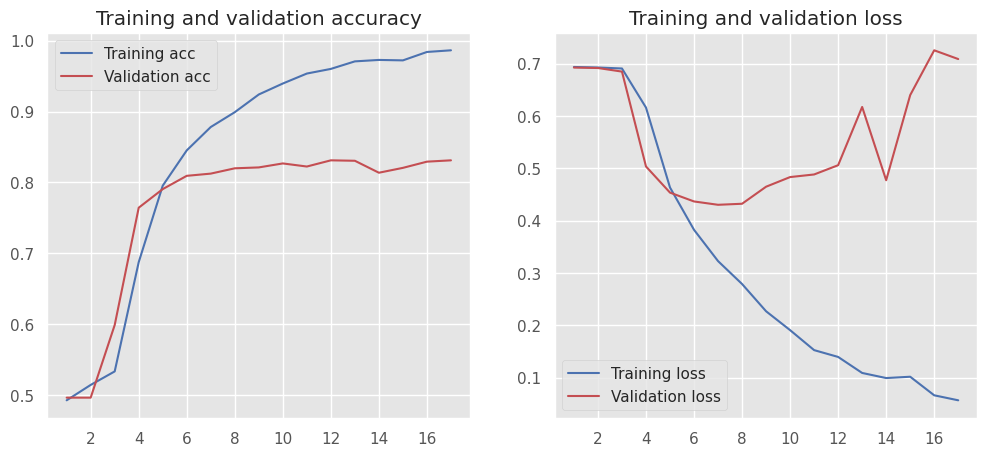

In [76]:
model = EmbeddingLSTMClassifier(vocab_size=vocab_size,
    embedding_dim=200,
    hidden_dims=[128, 64],
    num_classes=num_classes,
    lstm_hidden_dim=128,
    lstm_layers=2,
    bidirectional=False,
    dropout=0.5)

print_model_params(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

model, history = train_and_evaluate(
    model, 
    train_dataset, 
    valid_dataset,
    criterion,
    optimizer,
    num_epochs=80,
    patience=10
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.81      0.84      0.82      1025
    positive       0.82      0.79      0.81       975

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000

Confusion matrix: 
Confusion matrix, without normalization


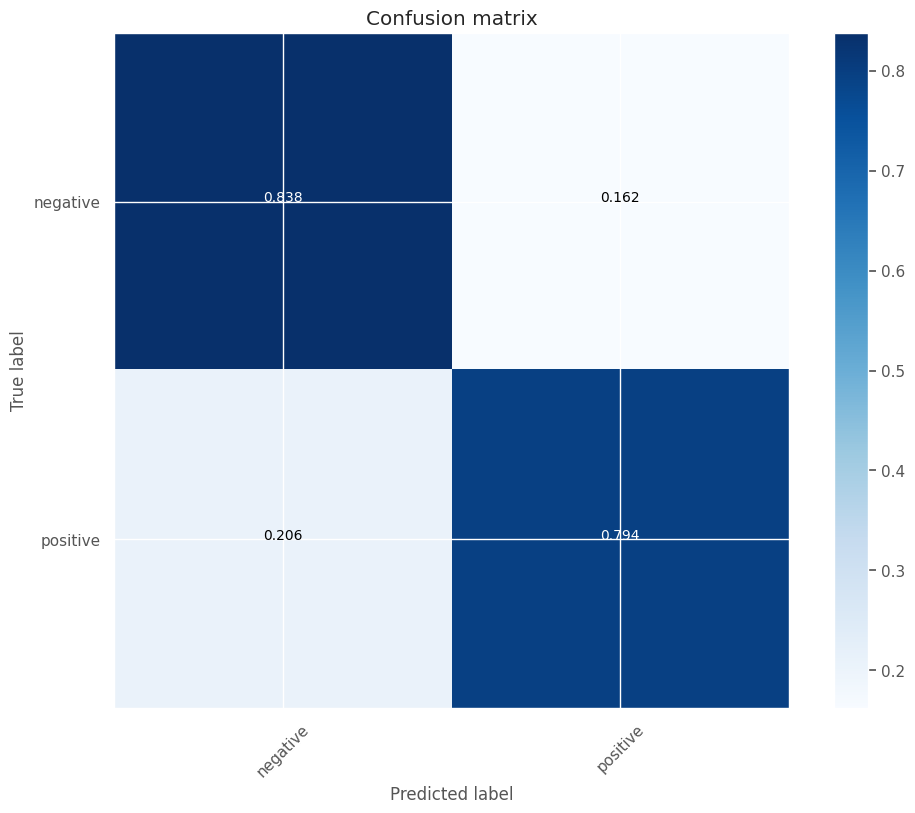

Overall metrics:
{'accuracy': 0.8165}


{'accuracy': 0.8165}

In [77]:
y_pred = predict_pytorch(model, X_test_tensor)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

Obtenemos ahora mejores resultados con una LSTM para longitudes de secuencia directamente de 300.

El entrenamiento es más estable. A partir de la 8 epoch, empieza a haber overfitting. Con **early stopping** se ha detectado que val loss no mejora y se ha parado el entrenamiento.
Ha sido más "fácil" encontrar hiper parámetros tales que hacen que este modelo aprenda y generalice hasta llegar a una accuracy de 81.65%. Esto no ha sido posible con RNN.

## ID=5 WE + LSTM Bidireccional

Como en inferencia tenemos acceso a toda la secuencia de entrada, podemos utilizar un modelo bidireccional.
Vamos a probar esto ahora:

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 8376400, shape: [41882, 200]
Name: lstm.weight_ih_l0, num params: 102400, shape: [512, 200]
Name: lstm.weight_hh_l0, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0, num params: 512, shape: [512]
Name: lstm.bias_hh_l0, num params: 512, shape: [512]
Name: lstm.weight_ih_l0_reverse, num params: 102400, shape: [512, 200]
Name: lstm.weight_hh_l0_reverse, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0_reverse, num params: 512, shape: [512]
Name: lstm.bias_hh_l0_reverse, num params: 512, shape: [512]
Name: lstm.weight_ih_l1, num params: 131072, shape: [512, 256]
Name: lstm.weight_hh_l1, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l1, num params: 512, shape: [512]
Name: lstm.bias_hh_l1, num params: 512, shape: [512]
Name: lstm.weight_ih_l1_reverse, num params: 131072

Epoch 1/80:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 200/200 [00:02<00:00, 79.77it/s]


Epoch 1/80:
Train Loss: 0.6938160079717636, Train Acc: 0.49578125
Val Loss: 0.6927877855300903, Val Acc: 0.49625



Epoch 2/80: 100%|██████████| 200/200 [00:02<00:00, 82.75it/s]


...

Epoch 14/80:
Train Loss: 0.053359039074275645, Train Acc: 0.9878125
Val Loss: 0.7589371374249458, Val Acc: 0.8225



Epoch 15/80: 100%|██████████| 200/200 [00:02<00:00, 83.58it/s]


Epoch 15/80:
Train Loss: 0.04921797349350527, Train Acc: 0.9865625
Val Loss: 0.6915333873033523, Val Acc: 0.831875



Epoch 16/80: 100%|██████████| 200/200 [00:02<00:00, 83.47it/s]


Epoch 16/80:
Train Loss: 0.03933470473159104, Train Acc: 0.99078125
Val Loss: 0.7309516726434231, Val Acc: 0.828125

Early stopping at epoch 16 (no improvement in 10 epochs)


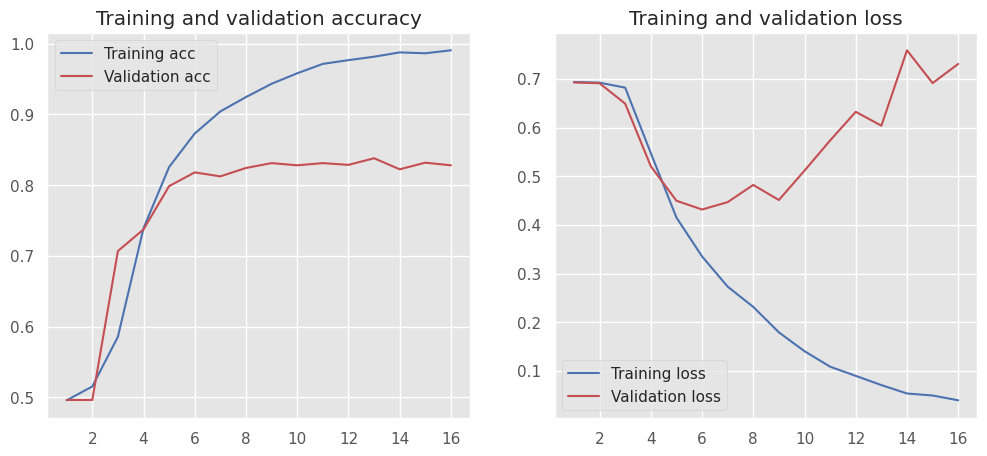

In [65]:
model = EmbeddingLSTMClassifier(vocab_size=vocab_size,
    embedding_dim=200,
    hidden_dims=[128, 64],
    num_classes=num_classes,
    lstm_hidden_dim=128,
    lstm_layers=2,
    bidirectional=True,
    dropout=0.5)

print_model_params(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

model, history = train_and_evaluate(
    model, 
    train_dataset, 
    valid_dataset,
    criterion,
    optimizer,
    num_epochs=80,
    patience=10
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.81      0.89      0.85      1025
    positive       0.87      0.78      0.82       975

    accuracy                           0.83      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.84      0.83      0.83      2000

Confusion matrix: 
Confusion matrix, without normalization


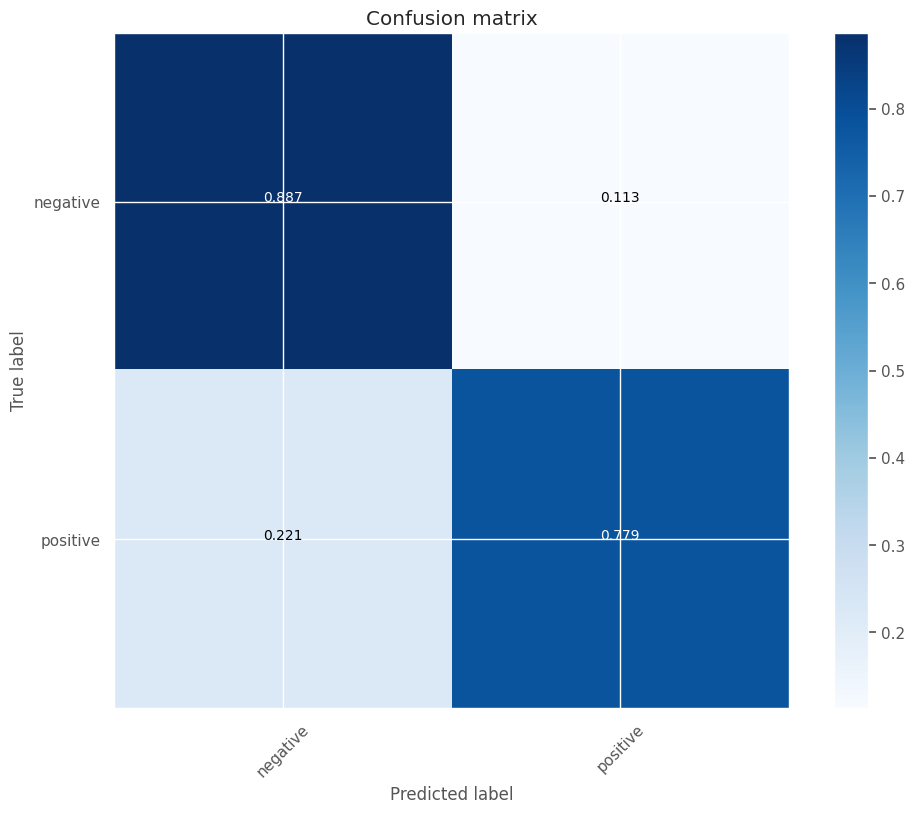

Overall metrics:
{'accuracy': 0.8345}


{'accuracy': 0.8345}

In [66]:
y_pred = predict_pytorch(model, X_test_tensor)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

Hemos obtenido una mejor accuracy en test en este caso 83.45% utilizando una LSTM bidireccional que unidireccional 80.4%.

Similar a anteriormente, también hay algo de overfitting a partir de la epoch 10 donde val loss incrementa y train loss disminuye. Early stopping ha parado el entrenamiento.

## ID=6 WE + GRU Bidireccional

Vamos a probar ahora en vez de con una LSTM, a utilizar una GRU:

https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html

Como utilizar reccurrencia bidireccional ha funcionado mejor, vamos a mantenerla en la GRU también.

In [67]:
class EmbeddingGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dims, num_classes,
                 gru_hidden_dim=128, gru_layers=1, bidirectional=True, dropout=0.5):
        super(EmbeddingGRUClassifier, self).__init__()

        # Capa de embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # GRU: similar a LSTM pero más simple (no tiene cell state)
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=gru_hidden_dim,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout
        )

        # Si es bidireccional, el output tiene el doble de dimensiones
        gru_output_dim = gru_hidden_dim * 2 if bidirectional else gru_hidden_dim

        # MLP
        layers = []
        input_dim = gru_output_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        embedded = self.embedding(x)       # [B, S, E]
        # La salida del forward de la GRU es:
        # gru_out, h_n
        # donde gru_out contiene las features de salida de la última
        # capa de la GRU para cada t de la Secuencia.
        gru_out, _ = self.gru(embedded)    # [B, S, gru_output_dim]
        pooled, _ = gru_out.max(dim=1)     # [B, gru_output_dim]
        output = self.mlp(pooled)          # [B, NC]
        return output

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 8376400, shape: [41882, 200]
Name: gru.weight_ih_l0, num params: 76800, shape: [384, 200]
Name: gru.weight_hh_l0, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l0, num params: 384, shape: [384]
Name: gru.bias_hh_l0, num params: 384, shape: [384]
Name: gru.weight_ih_l0_reverse, num params: 76800, shape: [384, 200]
Name: gru.weight_hh_l0_reverse, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l0_reverse, num params: 384, shape: [384]
Name: gru.bias_hh_l0_reverse, num params: 384, shape: [384]
Name: mlp.0.weight, num params: 32768, shape: [128, 256]
Name: mlp.0.bias, num params: 128, shape: [128]
Name: mlp.3.weight, num params: 8192, shape: [64, 128]
Name: mlp.3.bias, num params: 64, shape: [64]
Name: mlp.6.weight, num params: 128, shape: [2, 64]
Name: mlp.6.bias, num params: 2, s

Epoch 1/80:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 200/200 [00:00<00:00, 206.71it/s]


Epoch 1/80:
Train Loss: 0.6955349278450013, Train Acc: 0.495
Val Loss: 0.6920623970031738, Val Acc: 0.566875



Epoch 2/80: 100%|██████████| 200/200 [00:00<00:00, 208.07it/s]


...

Epoch 17/80:
Train Loss: 0.02436864807503298, Train Acc: 0.99640625
Val Loss: 0.5543139904737473, Val Acc: 0.829375



Epoch 18/80: 100%|██████████| 200/200 [00:00<00:00, 208.10it/s]


Epoch 18/80:
Train Loss: 0.015026693497784436, Train Acc: 0.99875
Val Loss: 0.5973827861249447, Val Acc: 0.833125



Epoch 19/80: 100%|██████████| 200/200 [00:00<00:00, 208.44it/s]


Epoch 19/80:
Train Loss: 0.012243185011902824, Train Acc: 0.99828125
Val Loss: 0.6786405855417251, Val Acc: 0.823125

Early stopping at epoch 19 (no improvement in 10 epochs)


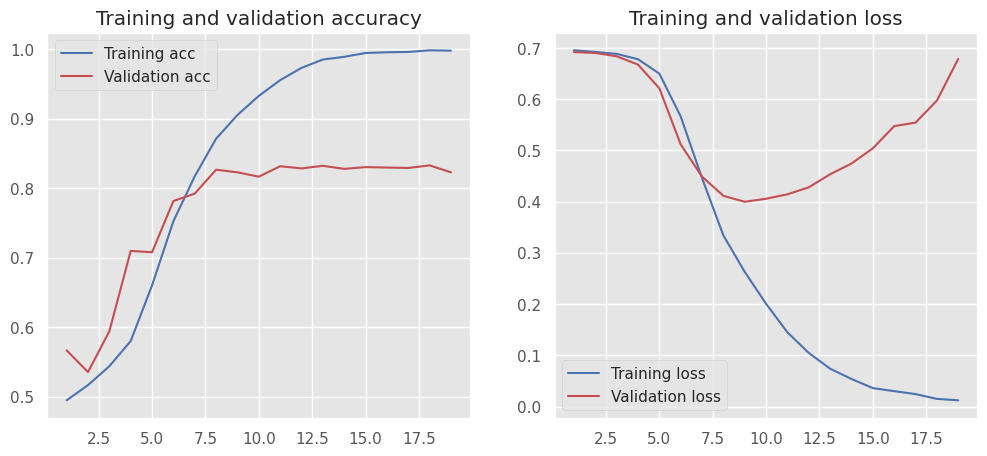

In [78]:
model = EmbeddingGRUClassifier(vocab_size=vocab_size,
    embedding_dim=200,
    hidden_dims=[128, 64],
    num_classes=num_classes,
    gru_hidden_dim=128,
    gru_layers=1,
    # Mantenemos la bidireccionalidad
    bidirectional=True,
    dropout=0.5)

print_model_params(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

model, history = train_and_evaluate(
    model, 
    train_dataset, 
    valid_dataset,
    criterion,
    optimizer,
    num_epochs=80,
    patience=10
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.88      0.75      0.81      1025
    positive       0.77      0.90      0.83       975

    accuracy                           0.82      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.83      0.82      0.82      2000

Confusion matrix: 
Confusion matrix, without normalization


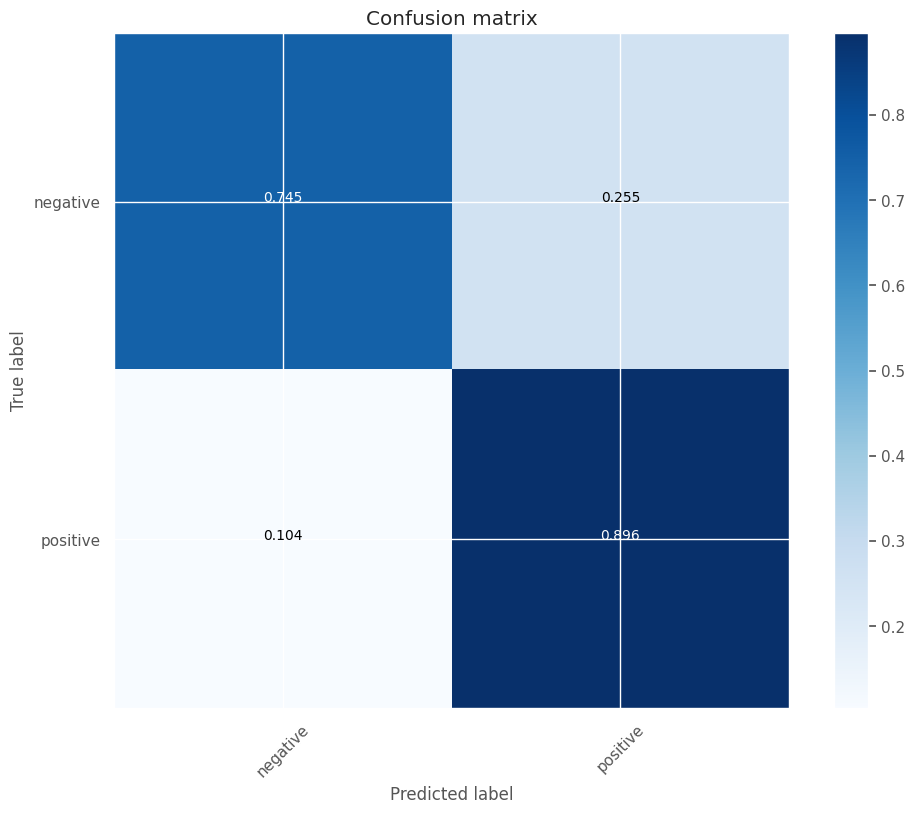

Overall metrics:
{'accuracy': 0.819}


{'accuracy': 0.819}

In [79]:
y_pred = predict_pytorch(model, X_test_tensor)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

Se obtiene un resultado similar a los entrenamientos de las LSTM. El entrenamiento es estable y se produce overfitting alrededor de la epoch número 11.

## ID=7 WE + GRU Stacked

Vamos a probar a utilizar capas GRU apiladas con el fin de conseguir features más "profundas" sobre el contexto de la secuencia.

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 8376400, shape: [41882, 200]
Name: gru.weight_ih_l0, num params: 76800, shape: [384, 200]
Name: gru.weight_hh_l0, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l0, num params: 384, shape: [384]
Name: gru.bias_hh_l0, num params: 384, shape: [384]
Name: gru.weight_ih_l0_reverse, num params: 76800, shape: [384, 200]
Name: gru.weight_hh_l0_reverse, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l0_reverse, num params: 384, shape: [384]
Name: gru.bias_hh_l0_reverse, num params: 384, shape: [384]
Name: gru.weight_ih_l1, num params: 98304, shape: [384, 256]
Name: gru.weight_hh_l1, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l1, num params: 384, shape: [384]
Name: gru.bias_hh_l1, num params: 384, shape: [384]
Name: gru.weight_ih_l1_reverse, num params: 98304, shape: [384, 25

Epoch 1/80:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 200/200 [00:01<00:00, 126.77it/s]


Epoch 1/80:
Train Loss: 0.6946620103716851, Train Acc: 0.49671875
Val Loss: 0.6919384443759918, Val Acc: 0.528125



Epoch 2/80: 100%|██████████| 200/200 [00:01<00:00, 127.58it/s]


...

Epoch 10/80:
Train Loss: 0.17843218304216862, Train Acc: 0.94453125
Val Loss: 0.5013680925965309, Val Acc: 0.8225



Epoch 11/80: 100%|██████████| 200/200 [00:01<00:00, 127.56it/s]


Epoch 11/80:
Train Loss: 0.1425374543387443, Train Acc: 0.95390625
Val Loss: 0.566445659995079, Val Acc: 0.82



Epoch 12/80: 100%|██████████| 200/200 [00:01<00:00, 127.63it/s]


Epoch 12/80:
Train Loss: 0.1282290188688785, Train Acc: 0.96125
Val Loss: 0.5600675636529923, Val Acc: 0.80375

Early stopping at epoch 12 (no improvement in 5 epochs)


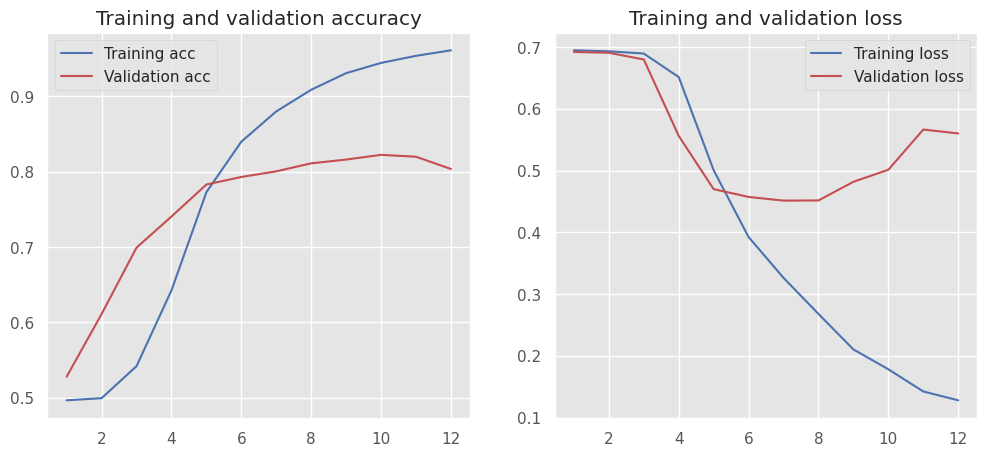

In [70]:
model = EmbeddingGRUClassifier(vocab_size=vocab_size,
    embedding_dim=200,
    hidden_dims=[128, 64],
    num_classes=num_classes,
    gru_hidden_dim=128,
    gru_layers=2,
    bidirectional=True,
    dropout=0.5)

print_model_params(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

model, history = train_and_evaluate(
    model, 
    train_dataset, 
    valid_dataset,
    criterion,
    optimizer,
    num_epochs=80,
    patience=5
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.78      0.88      0.83      1025
    positive       0.86      0.74      0.79       975

    accuracy                           0.81      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.82      0.81      0.81      2000

Confusion matrix: 
Confusion matrix, without normalization


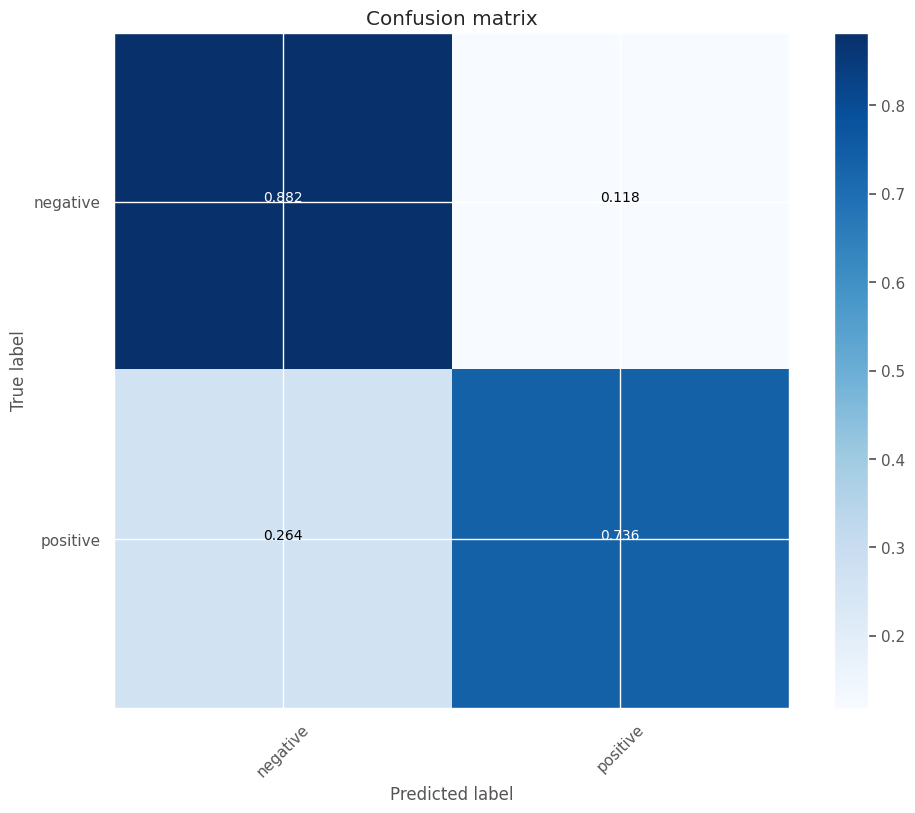

Overall metrics:
{'accuracy': 0.811}


{'accuracy': 0.811}

In [71]:
y_pred = predict_pytorch(model, X_test_tensor)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

Se obtiene un resultado algo peor. Creo que uno de los principales problemas que hay ahora es el overfitting. Quizá el modelo
tiene demasiados parámetros. En la recapitulación de los experimentos, veremos el número de parámetros.

## Resumen

Hasta ahora hemos realizado los siguientes experimentos:

| Experimento | Accuracy | Parámetros |
|--------|----------|------------|
| ID=1 WE + MLP |  77.75% | 12611514 |
| ID=2 WE + RNN | 48.65% | 4217898 |
| ID=3 WE + RNN (menor longitud secuencia) | 52.1% | 4217898 |
| ID=4 WE + LSTM Unidireccional | 81.65% | 8702354 |
| ID=5 WE + LSTM Bidireccional | 83.45% | 9150866 |
| ID=6 WE + GRU Bidireccional | 81.9% | 8671122 |
| ID=7 WE + GRU Stacked | 81.1% | 8967570 |

De estos primeros experimentos puedo extraer que:
- Es más fácil de entrenar redes recurrentes como LSTM o GRU que la estandar RNN. Diría que las LSTM, GRU
incorporan elementos que hacen que el entrenamiento sea estable y el flujo de gradientes no desvanezca para secuencias relativamente largas.
- El uso de recurrencia Bidireccional ha aumentado la accuracy un poco.

Del desglose del número de parámetros, veo que la mayor parte de los parámetros de estas redes se encuentran en la **capa de embedding**. Por ejemplo:
- ID=1 WE + MLP. Total params = 12611514. Embedding params (300) = 12564600
- ID=5 WE + LSTM Bidireccional. Total params = 9150866. Embedding params (200) = 8376400

Es posible que el gran número de parámetros de la capa de embedding aumente la probabilidad de overfitting. Por este motivo, en apartados siguientes
utilizaremos directamente embedding pre entrenados. Pero a continuación vamos a cambiar la técnica de batching.

Para combatir el overfitting hemos utilizado:
- Early stopping (Para el entrenamiento cuando val loss no mejora después de un número determinado de epochs).
- Dropout: Desconectar neuronas durante entrenamiento para crear redundancias.

# Longitud de secuencia variable (dynamic batching)

A continuación quiero experimentar con dynamic batching.
Con esta técnica, vamos a hacer que cada muestra del mini batch tenga la longitud de la muestra de longitud máxima del batch.

Por ejemplo, si tenemos un batch de 4 donde tenemos las siguientes longitudes [102, 150, 123, 140], en vez de convertir estas longitudes a [300,300,300,300], vamos a convertirlas a [150,150,150,150].
Así, como las redes recurrentes pueden procesar secuencias de distinta longitud podemos seguir aprovechando la paralelización con batches y quizá reducir el ruido que aporta el token de padding.

Así se procesarán batches de diferente longitud y esperamos que el token de padding añada menos ruido al entrenamiento.

Empezamos creando un dataset de pytorch para guardar las secuencias sin añadir el token de padding. Solo se recortan aquellas superiores a 300 tokens.
Pero mantenemos la longitud de las secuencias más cortas.

In [34]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split

MAX_LENGTH = 300

class TextDataset(Dataset):
    def __init__(self, sequences, labels, max_length=300):
        self.sequences = sequences
        self.labels = labels
        self.max_length = max_length
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        # Truncamos ya hacia la longitud máxima
        # Pero no padeamos las secuencias más cortas
        seq = self.sequences[idx][:self.max_length]
        seq = torch.tensor(seq, dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return seq, label

In [35]:
# Construimos el dataset de entrenamiento y el dataset de validación
from sklearn.model_selection import train_test_split

train_seqs, valid_seqs, y_train, y_valid = train_test_split(
    train_sequences,
    encoded_y_train,
    test_size=0.2,
    random_state=42,
)

# Create datasets (NO padding happens here)
train_text_dataset = TextDataset(train_seqs, y_train, max_length=MAX_LENGTH)
valid_text_dataset = TextDataset(valid_seqs, y_valid, max_length=MAX_LENGTH)
test_text_dataset  = TextDataset(test_sequences, encoded_y_test, max_length=MAX_LENGTH)

Definimos la siguiente función que se pasará a los DataLoaders y se llamará a la hora de generar los batches.
Esta funcion va a padear las secuencias para que alcancen la longitud de la secuencia máxima del batch.

In [36]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

def dynamic_batch_fn(batch):
    sequences, labels = zip(*batch)

    lengths = torch.tensor([len(seq) for seq in sequences])
    padded = pad_sequence(sequences, batch_first=True, padding_value=0)

    labels = torch.tensor(labels)

    return padded, labels, lengths

Defino una función para predecir en test a la que se le pueda pasar también la collate_fn que implementa el dynamic batching.
En la siguiente celda vemos como funciona:

In [37]:
# Entrada con vectores de longitud variable
sequences = [
    torch.tensor([5, 3, 8]),
    torch.tensor([1, 7]),
    torch.tensor([4, 2, 9, 6, 1]),
    torch.tensor([3]),
]
labels = [1, 0, 1, 0]

# Simulamos un batch
batch = list(zip(sequences, labels))

# Aplicamos la función
padded, labels, lengths = dynamic_batch_fn(batch)

print(f"Después de pad_sequence (paddea al máximo del batch = {lengths.max()}):")
print(padded)

print(f"Longitudes reales:")
print(lengths)

print(f"Labels:")
print(labels)

Después de pad_sequence (paddea al máximo del batch = 5):
tensor([[5, 3, 8, 0, 0],
        [1, 7, 0, 0, 0],
        [4, 2, 9, 6, 1],
        [3, 0, 0, 0, 0]])
Longitudes reales:
tensor([3, 2, 5, 1])
Labels:
tensor([1, 0, 1, 0])


In [38]:
def predict_text_pytorch(model, dataset, batch_size=32, collate_fn=None,
                    device='cuda' if torch.cuda.is_available() else 'cpu', pass_lengths=False):
    model = model.to(device)
    model.eval()

    # Data loader con dynamic batching
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    all_preds = []

    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                batch_X, _, lengths = batch
                batch_X = batch_X.to(device)
                lengths = lengths.to(device)

                if pass_lengths:
                    outputs = model(batch_X, lengths)
                else:
                    outputs = model(batch_X)
            else:
                batch_X, _ = batch
                batch_X = batch_X.to(device)
                outputs = model(batch_X)
            
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
    
    return np.array(all_preds)

## ID=8 WE + LSTM Bidireccional Dynamic Batching

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 8376400, shape: [41882, 200]
Name: lstm.weight_ih_l0, num params: 102400, shape: [512, 200]
Name: lstm.weight_hh_l0, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0, num params: 512, shape: [512]
Name: lstm.bias_hh_l0, num params: 512, shape: [512]
Name: lstm.weight_ih_l0_reverse, num params: 102400, shape: [512, 200]
Name: lstm.weight_hh_l0_reverse, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0_reverse, num params: 512, shape: [512]
Name: lstm.bias_hh_l0_reverse, num params: 512, shape: [512]
Name: lstm.weight_ih_l1, num params: 131072, shape: [512, 256]
Name: lstm.weight_hh_l1, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l1, num params: 512, shape: [512]
Name: lstm.bias_hh_l1, num params: 512, shape: [512]
Name: lstm.weight_ih_l1_reverse, num params: 131072

Epoch 1/80:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 400/400 [00:03<00:00, 123.98it/s]


Epoch 1/80:
Train Loss: 0.6947190821170807, Train Acc: 0.49046875
Val Loss: 0.6934952414035798, Val Acc: 0.49625



Epoch 2/80: 100%|██████████| 400/400 [00:03<00:00, 123.65it/s]


...

Epoch 13/80:
Train Loss: 0.04639233239082387, Train Acc: 0.9875
Val Loss: 0.7384395497944206, Val Acc: 0.82375



Epoch 14/80: 100%|██████████| 400/400 [00:03<00:00, 125.06it/s]


Epoch 14/80:
Train Loss: 0.04176299510007084, Train Acc: 0.9890625
Val Loss: 0.7863215312827379, Val Acc: 0.810625



Epoch 15/80: 100%|██████████| 400/400 [00:03<00:00, 123.74it/s]


Epoch 15/80:
Train Loss: 0.027483017285558162, Train Acc: 0.99375
Val Loss: 0.7600052967853844, Val Acc: 0.828125

Early stopping at epoch 15 (no improvement in 10 epochs)


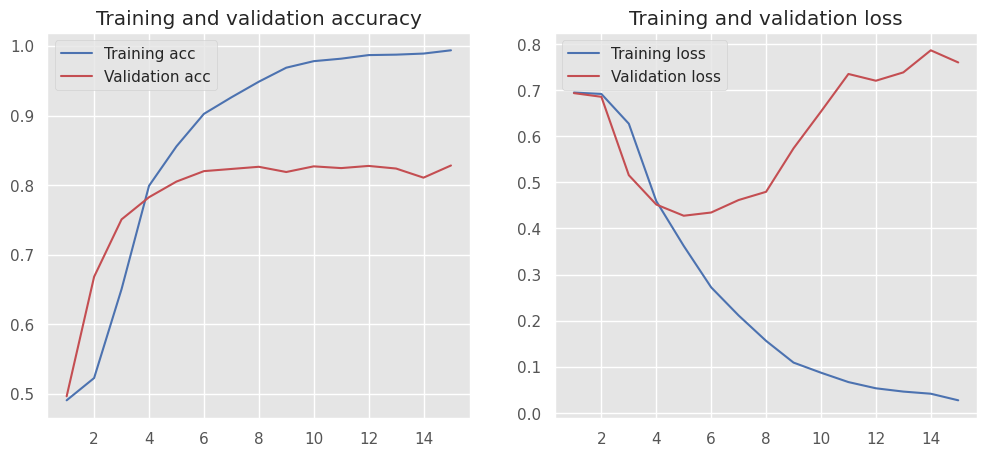

In [125]:
model = EmbeddingLSTMClassifier(vocab_size=vocab_size,
    embedding_dim=200,
    hidden_dims=[128, 64],
    num_classes=num_classes,
    lstm_hidden_dim=128,
    lstm_layers=2,
    bidirectional=True,
    dropout=0.5)

print_model_params(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

model, history = train_and_evaluate(
    model, 
    train_text_dataset, 
    valid_text_dataset,
    criterion,
    optimizer,
    num_epochs=80,
    patience=10,
    batch_size=16,
    collate_fn=dynamic_batch_fn
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.87      0.77      0.81      1025
    positive       0.78      0.88      0.83       975

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.83      0.82      0.82      2000

Confusion matrix: 
Confusion matrix, without normalization


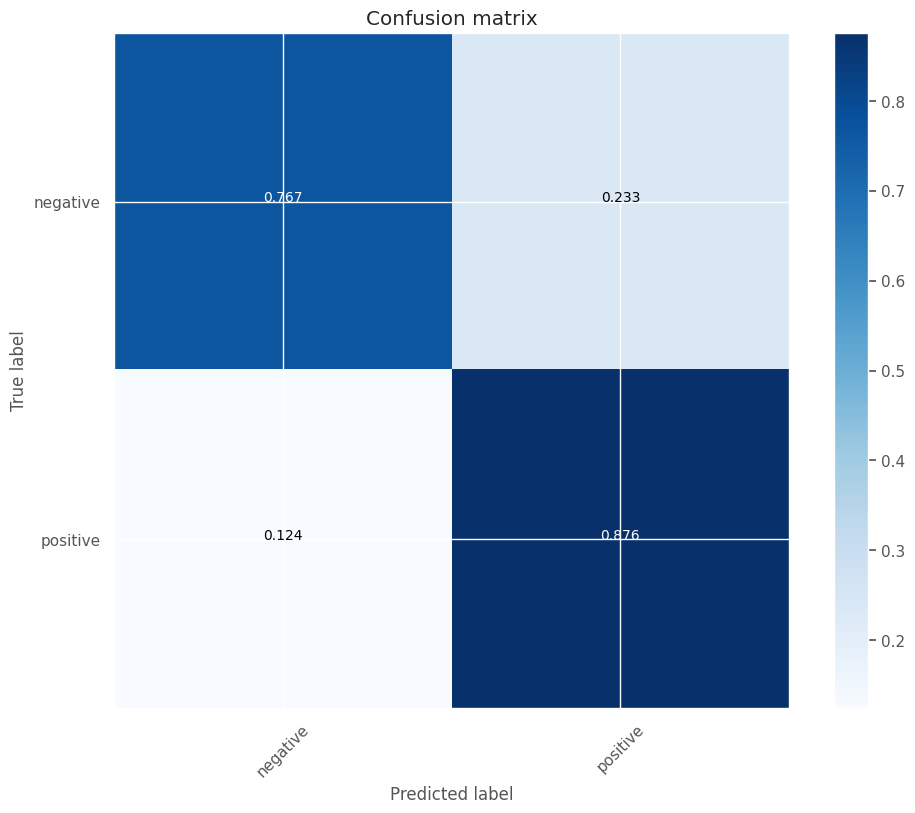

Overall metrics:
{'accuracy': 0.82}


{'accuracy': 0.82}

In [126]:
y_pred = predict_text_pytorch(model, test_text_dataset, batch_size=16, collate_fn=dynamic_batch_fn)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

Obtenemos un resultado similar al obtenido con longitudes de secuencia de 300.

## ID=9 WE + RNN - Dynamic Batching

Voy a probar si ahora un modelo basado en RNN obtiene mejores resultados con Dynamic Batching.
Utilizaré un batch pequeño para reducir la probabilidad de secuencias largas.

Epoch 1/80:   0%|          | 0/1600 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 1600/1600 [00:04<00:00, 392.18it/s]


Epoch 1/80:
Train Loss: 0.7170278118364513, Train Acc: 0.50109375
Val Loss: 0.69320003464818, Val Acc: 0.51



Epoch 2/80: 100%|██████████| 1600/1600 [00:04<00:00, 393.55it/s]


Epoch 2/80:
Train Loss: 0.7124351157434284, Train Acc: 0.499375
Val Loss: 0.6949884329736232, Val Acc: 0.5



...

Epoch 19/80:
Train Loss: 0.712033382281661, Train Acc: 0.50109375
Val Loss: 0.7024173758924007, Val Acc: 0.51375



Epoch 20/80: 100%|██████████| 1600/1600 [00:04<00:00, 394.21it/s]


Epoch 20/80:
Train Loss: 0.7138467942178249, Train Acc: 0.50078125
Val Loss: 0.707984360679984, Val Acc: 0.51125



Epoch 21/80: 100%|██████████| 1600/1600 [00:04<00:00, 393.86it/s]


Epoch 21/80:
Train Loss: 0.7103387633524835, Train Acc: 0.4921875
Val Loss: 0.7226746480166912, Val Acc: 0.505

Early stopping at epoch 21 (no improvement in 20 epochs)


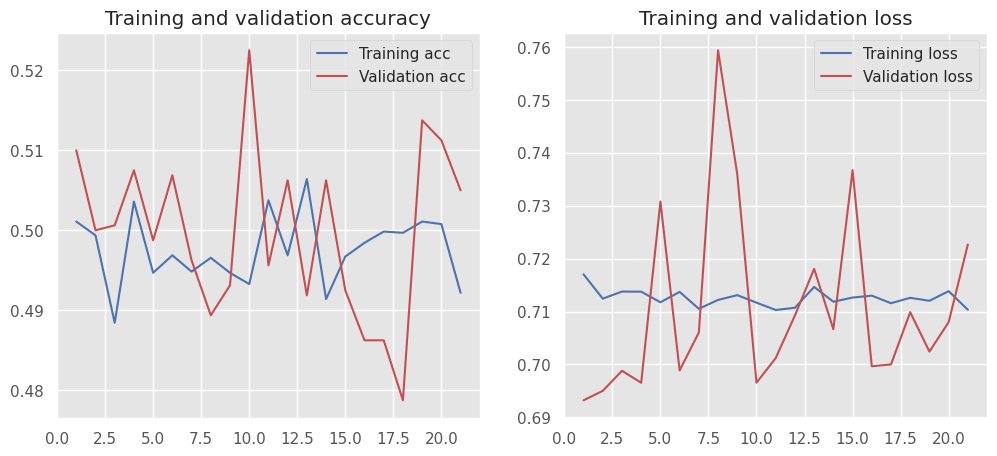

In [ ]:
num_classes = 2
model = EmbeddingRNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_classes=num_classes,
    num_layers=1,
    dropout=0.3
)

print_model_params(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0001)

model, history = train_and_evaluate(
    model, 
    train_text_dataset, 
    valid_text_dataset,
    criterion,
    optimizer,
    num_epochs=epochs,
    batch_size=4,
    patience=20,
    collate_fn=dynamic_batch_fn
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.47      0.14      0.22      1025
    positive       0.48      0.84      0.61       975

    accuracy                           0.48      2000
   macro avg       0.48      0.49      0.41      2000
weighted avg       0.48      0.48      0.41      2000

Confusion matrix: 
Confusion matrix, without normalization


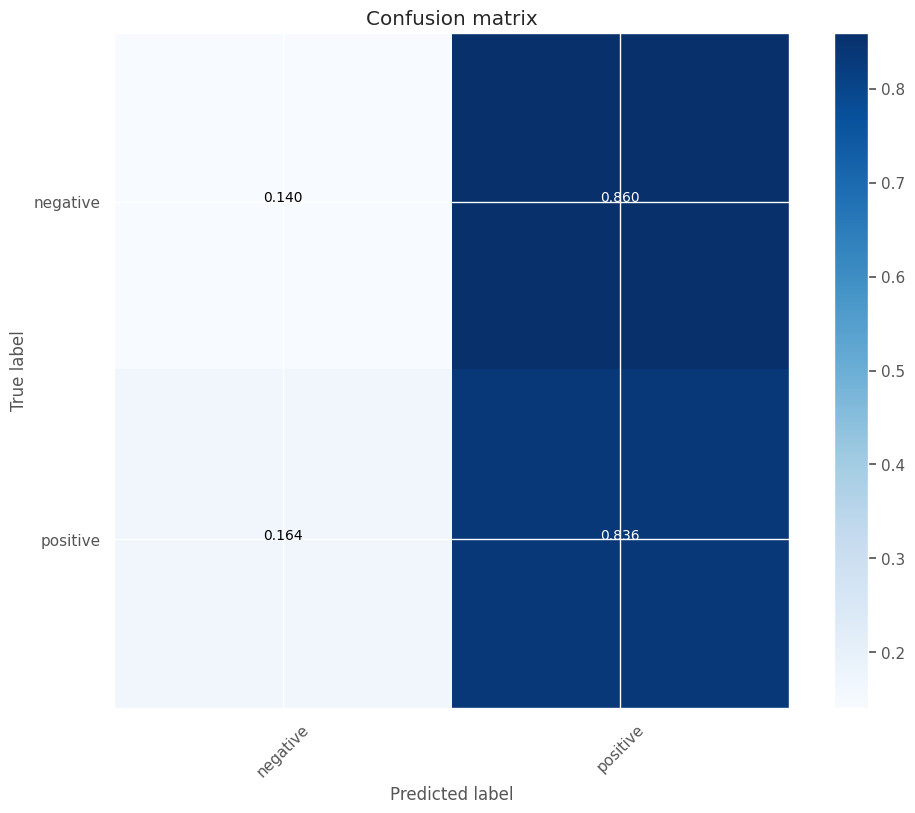

Overall metrics:
{'accuracy': 0.4795}


{'accuracy': 0.4795}

In [88]:
y_pred = predict_text_pytorch(model, test_text_dataset, batch_size=16, collate_fn=dynamic_batch_fn)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

No mejora el resultado usar Dynamic Batching con WE + RNN.

## Experiment sweep Batch

Me gustaría sistematizar la exploración del tamaño del Batch. Voy
a probar los siguientes batch sizes:
[4, 8, 16, 32, 64, 128]

Se entrena un modelo para cada tamaño de batch y se guarda el histórico de cada entrenamiento.
Al final se crea un gráfico con todas las pérdidas en validación y accuracies en validación para comparar.

-----------------
Training with batch_size: 4
-----------------


Epoch 1/80:   0%|          | 0/1600 [00:00<?, ?it/s]

Epoch 9/80: 100%|██████████| 1600/1600 [00:12<00:00, 126.67it/s]


Early stopping at epoch 9 (no improvement in 5 epochs)
-----------------
Training with batch_size: 8
-----------------


Epoch 8/80: 100%|██████████| 800/800 [00:07<00:00, 105.04it/s]


...

Early stopping at epoch 12 (no improvement in 5 epochs)
-----------------
Training with batch_size: 64
-----------------


Epoch 12/80: 100%|██████████| 100/100 [00:01<00:00, 55.65it/s]


Early stopping at epoch 12 (no improvement in 5 epochs)
-----------------
Training with batch_size: 128
-----------------


Epoch 17/80: 100%|██████████| 50/50 [00:01<00:00, 34.39it/s]


Early stopping at epoch 17 (no improvement in 5 epochs)


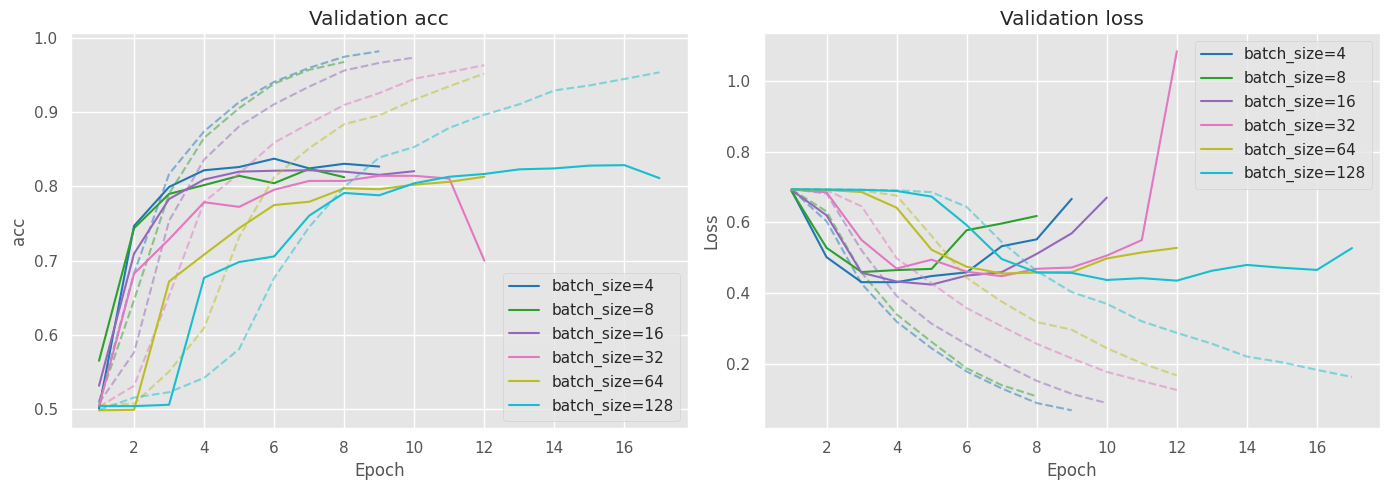

In [ ]:
batch_sizes = [4, 8, 16, 32, 64, 128]
histories = []
names = []

for bs in batch_sizes:
    print(f"-----------------")
    print(f"Training with batch_size: {bs}")
    print(f"-----------------")

    print_model_params(model)

    model = EmbeddingLSTMClassifier(vocab_size=vocab_size,
        embedding_dim=200,
        hidden_dims=[128, 64],
        num_classes=num_classes,
        lstm_hidden_dim=128,
        lstm_layers=2,
        bidirectional=True,
        dropout=0.5)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.0001)

    model, history = train_and_evaluate(
        model, 
        train_text_dataset, 
        valid_text_dataset,
        criterion,
        optimizer,
        num_epochs=80,
        patience=5,
        collate_fn=dynamic_batch_fn,
        batch_size=bs,
        verbose=False
    )

    histories.append(history)
    names.append(f"batch_size={bs}")

plot_histories(histories, names)

Más o menos todos los tamaños de batch alcancan la misma accuracy en validación.
Se puede ver que con un batch más pequeño se alcanza antes una buena accuracy en validación. Con un batch más grande se necesitan más epochs para alcanzarla, pero
se tarda más también en hacer overfitting.

Nótese también que una epoch con batch size 4 tarda 12 segundos, mientras que con batch size 128 tarda 1s porque se aprovecha la paralelización de la GPU.

## Experiment sweep Learning rate

Quiero ver ahora como afecta el learning rate a un modelo con una LSTM. Para eso ahora, mantenemos el batch fijo y hacemos un sweep del learning rate.
Uso un batch size de 16 (relativamente intermedio).

-----------------
Training with lr: 0.01
-----------------


Epoch 1/80:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 8/80: 100%|██████████| 400/400 [00:04<00:00, 88.81it/s]


Early stopping at epoch 8 (no improvement in 5 epochs)
-----------------
Training with lr: 0.001
-----------------


Epoch 7/80: 100%|██████████| 400/400 [00:04<00:00, 88.76it/s]


Early stopping at epoch 7 (no improvement in 5 epochs)
-----------------
Training with lr: 0.0005
-----------------


Epoch 8/80: 100%|██████████| 400/400 [00:04<00:00, 88.97it/s]


Early stopping at epoch 8 (no improvement in 5 epochs)
-----------------
Training with lr: 0.0001
-----------------


Epoch 11/80: 100%|██████████| 400/400 [00:04<00:00, 89.32it/s]


Early stopping at epoch 11 (no improvement in 5 epochs)


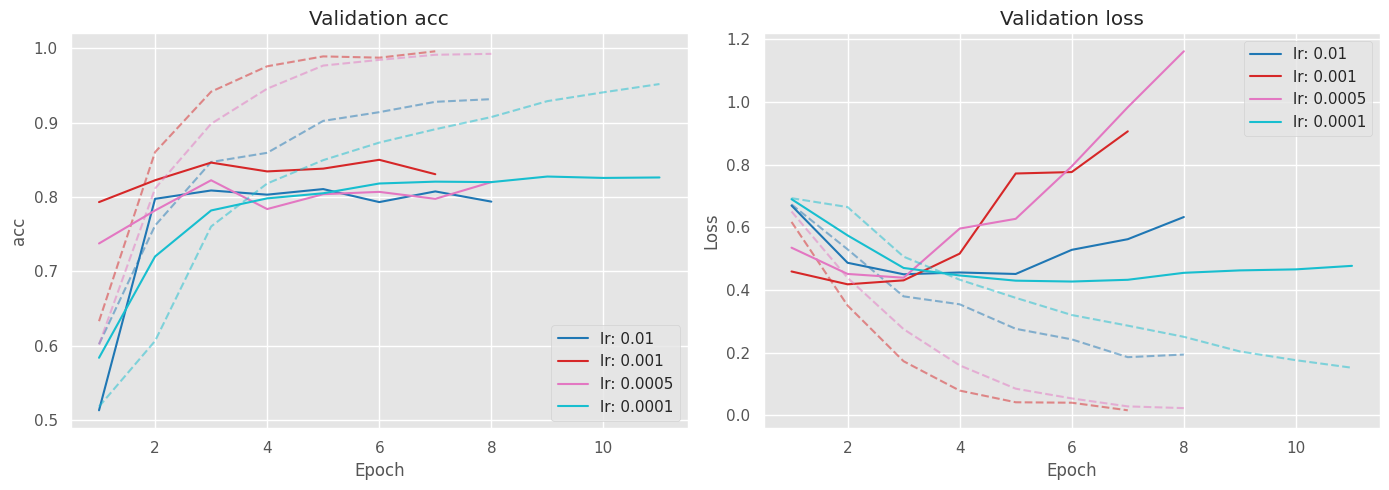

In [ ]:
learning_rates = [0.01, 0.001, 0.0005, 0.0001]
histories = []
names = []

BATCH_SIZE = 16

for lr in learning_rates:
    print(f"-----------------")
    print(f"Training with lr: {lr}")
    print(f"-----------------")

    model = EmbeddingLSTMClassifier(vocab_size=vocab_size,
        embedding_dim=200,
        hidden_dims=[128, 64],
        num_classes=num_classes,
        lstm_hidden_dim=128,
        lstm_layers=2,
        bidirectional=True,
        dropout=0.5)

    print_model_params(model)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    model, history = train_and_evaluate(
        model, 
        train_text_dataset, 
        valid_text_dataset,
        criterion,
        optimizer,
        num_epochs=80,
        patience=5,
        collate_fn=dynamic_batch_fn,
        batch_size=BATCH_SIZE,
        verbose=False
    )

    histories.append(history)
    names.append(f"lr: {lr}")

plot_histories(histories, names)

Se puede ver que este modelo con un optimizador **AdamW** es algo robusto ante diferentes ratios de aprendizaje.
Parece que el que mejor accuracy alcanza en validación es 0.001.

# Packing

Packing es una técnica en la que se le informa a la red recurrente sobre la longitud de la secuencia (sin incluir los últimos tokens de padding) y
la red recurrente procesa en cada paso "temporal" solamente hasta esta longitud e ignora los tokens de padding.

Es algo más eficiente y quizá reduce ruido por el token de padding al tratar con secuencias de tamaño variable.

La documentación de la LSTM y GRU muestra que:
https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html

"The input can also be a packed variable length sequence. See torch.nn.utils.rnn.pack_padded_sequence() or torch.nn.utils.rnn.pack_sequence() for details"

In [39]:
import torch
import torch.nn as nn

class EmbeddingLSTMClassifierPack(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dims, num_classes,
                 lstm_hidden_dim=128, lstm_layers=1, bidirectional=True, dropout=0.5):
        super(EmbeddingLSTMClassifierPack, self).__init__()

        # Capa de embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # LSTM: procesa la secuencia y captura dependencias temporales
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout
        )

        # Si es bidireccional, el output tiene el doble de dimensiones
        # Las features de derecha a izquierda y de izquierda a derecha de la secuencia.
        lstm_output_dim = lstm_hidden_dim * 2 if bidirectional else lstm_hidden_dim

        # MLP
        layers = []
        input_dim = lstm_output_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x, lengths):
        embedded = self.embedding(x)  # [B, S, E]
        # Empaquetamos las secuencias para que la LSTM no procese el padding
        packed = pack_padded_sequence(embedded, lengths.cpu(), 
                                    batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        # Desempaquetamos para volver a tensor
        lstm_out, _ = pad_packed_sequence(packed_out, batch_first=True)

        pool, _ = lstm_out.max(dim=1)  # [B, lstm_output_dim]
        output = self.mlp(pool)
        return output

In [40]:
def packing_collate_fn(batch):
    sequences, labels = zip(*batch)

    lengths = torch.tensor([len(seq) for seq in sequences])

    sequences = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.stack(labels)

    return sequences, labels, lengths

In [41]:
sequences = [
    torch.tensor([5, 3, 8]),
    torch.tensor([1, 7]),
    torch.tensor([4, 2, 9, 6, 1]),
    torch.tensor([3]),
]
labels = [torch.tensor(1), torch.tensor(0), torch.tensor(1), torch.tensor(0)]

batch = list(zip(sequences, labels))

# Aplicamos la función
padded, labels_out, lengths = packing_collate_fn(batch)

print(f"Después de pad_sequence (paddea al máximo del batch = {lengths.max().item()}):")
print(padded)

print(f"Longitudes reales:")
print(lengths)

Después de pad_sequence (paddea al máximo del batch = 5):
tensor([[5, 3, 8, 0, 0],
        [1, 7, 0, 0, 0],
        [4, 2, 9, 6, 1],
        [3, 0, 0, 0, 0]])
Longitudes reales:
tensor([3, 2, 5, 1])


## ID=9 LSTM Bidireccional - DB - Packing

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 8376400, shape: [41882, 200]
Name: lstm.weight_ih_l0, num params: 102400, shape: [512, 200]
Name: lstm.weight_hh_l0, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0, num params: 512, shape: [512]
Name: lstm.bias_hh_l0, num params: 512, shape: [512]
Name: lstm.weight_ih_l0_reverse, num params: 102400, shape: [512, 200]
Name: lstm.weight_hh_l0_reverse, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0_reverse, num params: 512, shape: [512]
Name: lstm.bias_hh_l0_reverse, num params: 512, shape: [512]
Name: lstm.weight_ih_l1, num params: 131072, shape: [512, 256]
Name: lstm.weight_hh_l1, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l1, num params: 512, shape: [512]
Name: lstm.bias_hh_l1, num params: 512, shape: [512]
Name: lstm.weight_ih_l1_reverse, num params: 131072

Epoch 1/80:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 400/400 [00:07<00:00, 51.19it/s]


Epoch 1/80:
Train Loss: 0.6934928295016288, Train Acc: 0.50796875
Val Loss: 0.6902982532978058, Val Acc: 0.61375



Epoch 2/80: 100%|██████████| 400/400 [00:07<00:00, 53.05it/s]


...

Epoch 14/80:
Train Loss: 0.05198752405805863, Train Acc: 0.9871875
Val Loss: 0.7069222612911835, Val Acc: 0.825



Epoch 15/80: 100%|██████████| 400/400 [00:07<00:00, 52.91it/s]


Epoch 15/80:
Train Loss: 0.04500800219626399, Train Acc: 0.9884375
Val Loss: 0.7051069052400999, Val Acc: 0.831875



Epoch 16/80: 100%|██████████| 400/400 [00:07<00:00, 51.45it/s]


Epoch 16/80:
Train Loss: 0.0299982832371461, Train Acc: 0.99203125
Val Loss: 0.8515501109650359, Val Acc: 0.834375

Early stopping at epoch 16 (no improvement in 10 epochs)


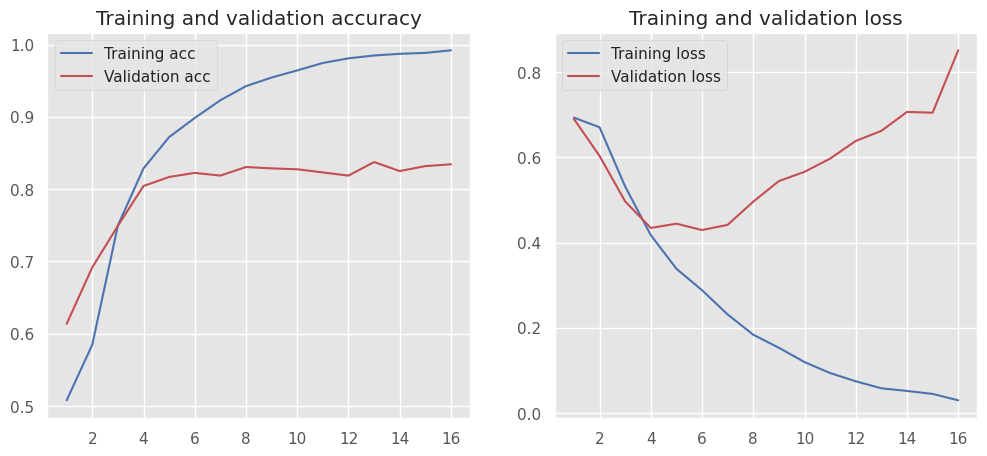

In [120]:
model = EmbeddingLSTMClassifierPack(vocab_size=vocab_size,
    embedding_dim=200,
    hidden_dims=[128, 64],
    num_classes=num_classes,
    lstm_hidden_dim=128,
    lstm_layers=2,
    bidirectional=True,
    dropout=0.5)

print_model_params(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

model, history = train_and_evaluate(
    model, 
    train_text_dataset, 
    valid_text_dataset,
    criterion,
    optimizer,
    num_epochs=80,
    patience=10,
    batch_size=16,
    collate_fn=packing_collate_fn,
    pass_lengths=True
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.83      0.84      0.84      1025
    positive       0.83      0.82      0.82       975

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000

Confusion matrix: 
Confusion matrix, without normalization


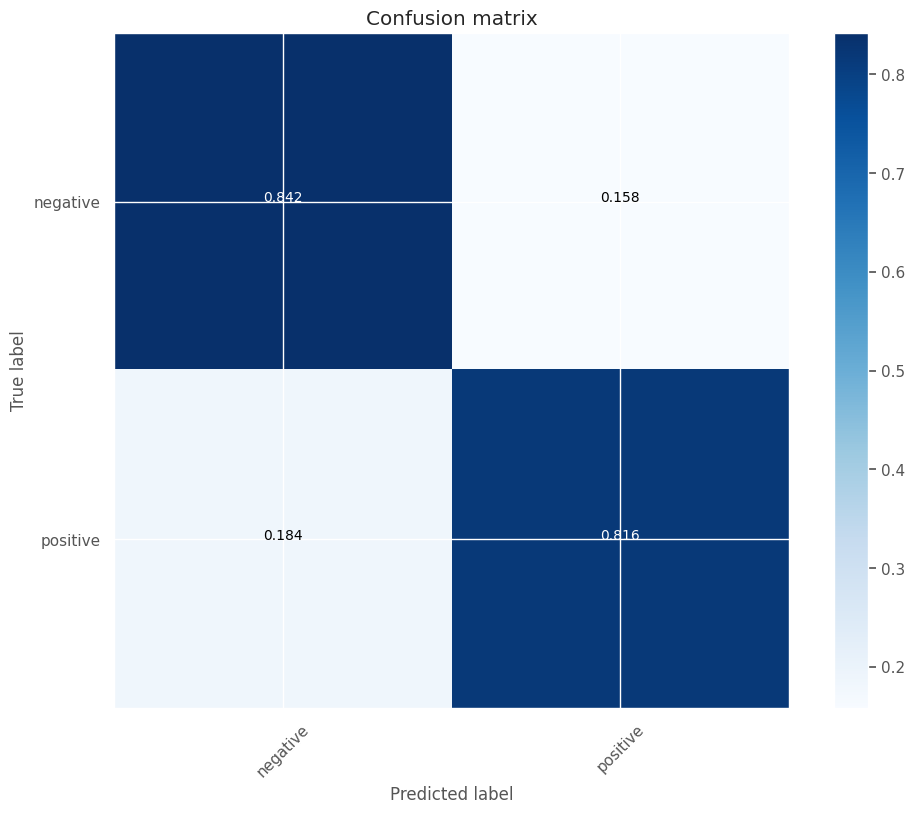

Overall metrics:
{'accuracy': 0.8295}


{'accuracy': 0.8295}

In [122]:
y_pred = predict_text_pytorch(model, test_text_dataset, batch_size=16, collate_fn=packing_collate_fn, pass_lengths=True)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

Se sigue obteniendo un resultado similar al sin usar dynamic batching ni packing.

# Pre trained Word Embeddings

Hemos visto antes que el mayor número de parámetros en los modelos que estamos entrenando, se encuentran en la capa de embeddings. Por ejemplo:
- ID=1 WE + MLP. Total params = 12611514. Embedding params (300) = 12564600
- ID=5 WE + LSTM Bidireccional. Total params = 9150866. Embedding params (200) = 8376400

Creo entonces, que se podría mejorar el modelo a partir de utilizar embeddings pre entrenados.

Voy a emplear embeddings basados en **Glove** de tamaño **100**.

In [42]:
import urllib.request
import zipfile
import os
import numpy as np

def download_glove(glove_dir='glove', dim=100):
    os.makedirs(glove_dir, exist_ok=True)
    glove_path = os.path.join(glove_dir, f'glove.6B.{dim}d.txt')

    # Revisamos si ya existe en nuestro directorio.
    # Tarda un poco la descarga, así no gastamos tiempo si ya está
    if not os.path.exists(glove_path):
        zip_path = os.path.join(glove_dir, 'glove.6B.zip')
        urllib.request.urlretrieve(
            'https://nlp.stanford.edu/data/glove.6B.zip', 
            zip_path
        )
        print("Extracting...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(glove_dir)
        os.remove(zip_path)
        print("Done!")
    else:
        print(f"GloVe already exists at {glove_path}")

    return glove_path

glove_path = download_glove(dim=100)  # Options: 50, 100, 200, 300

GloVe already exists at glove/glove.6B.100d.txt


Creo una función que dado un path, carga GloVe. Se guarda una estructura que funciona como un diccionario
donde las keys son palabras y los valores los vectores densos de longidud 100 en este caso.

In [43]:
def load_glove(glove_path):
    print(f"Loading GloVe from {glove_path}...")
    glove = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            glove[word] = vector
    print(f"Loaded {len(glove)} word vectors (dim={len(vector)})")
    return glove

glove = load_glove(glove_path)

# Comprobamos rápido el funcionamiento
# Para una palabra, tenemos un vector denso de tamaño 100
print(f"Word shape: (hello) = {glove['hello'].shape}")
print(f"Vector for hello {glove['hello'][:5]}...")

Loading GloVe from glove/glove.6B.100d.txt...
Loaded 400000 word vectors (dim=100)
Word shape: (hello) = (100,)
Vector for hello [ 0.26688  0.39632  0.6169  -0.77451 -0.1039 ]...


Quiero comprobar cuánto vocabulario hay del procesado en esta práctica en el modelo GloVe.

In [44]:
def check_coverage(word_index, glove):    
    found = []
    not_found = []
    
    for word in word_index:
        if word in glove:
            found.append(word)
        else:
            not_found.append(word)

    total = len(word_index)
    coverage = len(found) / total * 100
    
    print(f"Vocabulary size: {total}")
    print(f"Found in GloVe: {len(found)} ({coverage:.1f}%)")
    print(f"NOT found in GloVe: {len(not_found)} ({100-coverage:.1f}%)")
    print(f"Sample missing words: {not_found[:20]}")
    
    return found, not_found

found, not_found = check_coverage(word_index, glove)

Vocabulary size: 41881
Found in GloVe: 36890 (88.1%)
NOT found in GloVe: 4991 (11.9%)
Sample missing words: ['mordrid', 'zelah', 'elinore', 'trelkovsky', 'ossessione', 'louque', 'mukhsin', 'feinstone', 'imho', 'cassavettes', 'rotj', 'babban', 'vadar', 'sciamma', 'tetsur', 'gialli', 'scuddamore', 'syberberg', 'paperhouse', 'sjoman']


In [45]:
def build_embedding_matrix(word_index, glove, embedding_dim, vocab_size):
    embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)

    found_indices = []

    for word, idx in word_index.items():
        if idx >= vocab_size:
            continue
        if word in glove:
            embedding_matrix[idx] = glove[word]
            found_indices.append(idx)
        else:
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

    print(f"Pretrained: {len(found_indices)}/{vocab_size}")

    return embedding_matrix, found_indices

embedding_matrix, found_indices = build_embedding_matrix(word_index, glove, 100, vocab_size)

Pretrained: 36890/41882


## ID=10 LSTM - Bidireccional - PreTrained WE

In [183]:
class EmbeddingLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dims, num_classes,
                 lstm_hidden_dim=128, lstm_layers=1, bidirectional=True, dropout=0.5,
                 pretrained_embeddings=None):
        super(EmbeddingLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # Cargar los embedding pre entrenados si se pasan
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
            self.embedding.weight.data[0] = 0
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout
        )

        lstm_output_dim = lstm_hidden_dim * 2 if bidirectional else lstm_hidden_dim

        # MLP
        # Como anteriormente, Lineal, Relu, Dropout
        layers = []
        input_dim = lstm_output_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # Input [B, S]
        embedded = self.embedding(x)
        # Embedded [B, S, E]
        lstm_out, _ = self.lstm(embedded)    # [B, S, lstm_output_dim]
        pooled, _ = lstm_out.max(dim=1)      # [B, lstm_output_dim]
        output = self.mlp(pooled)            # [B, num_classes]
        return output

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 4188200, shape: [41882, 100]
Name: lstm.weight_ih_l0, num params: 51200, shape: [512, 100]
Name: lstm.weight_hh_l0, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0, num params: 512, shape: [512]
Name: lstm.bias_hh_l0, num params: 512, shape: [512]
Name: lstm.weight_ih_l0_reverse, num params: 51200, shape: [512, 100]
Name: lstm.weight_hh_l0_reverse, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0_reverse, num params: 512, shape: [512]
Name: lstm.bias_hh_l0_reverse, num params: 512, shape: [512]
Name: lstm.weight_ih_l1, num params: 131072, shape: [512, 256]
Name: lstm.weight_hh_l1, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l1, num params: 512, shape: [512]
Name: lstm.bias_hh_l1, num params: 512, shape: [512]
Name: lstm.weight_ih_l1_reverse, num params: 131072, 

Epoch 1/80:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 200/200 [00:01<00:00, 116.36it/s]


Epoch 1/80:
Train Loss: 0.6941744130849838, Train Acc: 0.5115625
Val Loss: 0.6891683888435364, Val Acc: 0.515625



Epoch 2/80: 100%|██████████| 200/200 [00:01<00:00, 116.34it/s]


...

Epoch 12/80:
Train Loss: 0.21113633388653397, Train Acc: 0.92953125
Val Loss: 0.41407676637172697, Val Acc: 0.84125



Epoch 13/80: 100%|██████████| 200/200 [00:01<00:00, 116.22it/s]


Epoch 13/80:
Train Loss: 0.19035266337916254, Train Acc: 0.93796875
Val Loss: 0.4051104357838631, Val Acc: 0.844375



Epoch 14/80: 100%|██████████| 200/200 [00:01<00:00, 116.35it/s]


Epoch 14/80:
Train Loss: 0.16923203063197434, Train Acc: 0.94671875
Val Loss: 0.427874516248703, Val Acc: 0.845

Early stopping at epoch 14 (no improvement in 5 epochs)


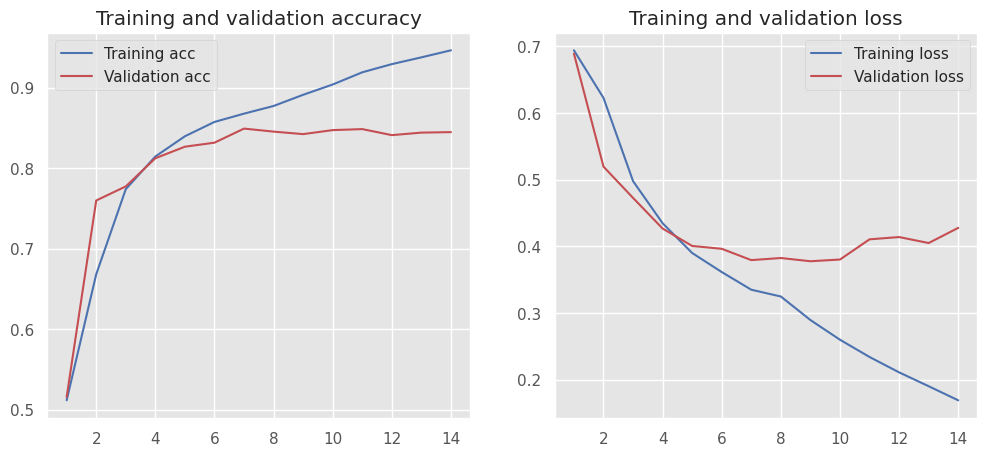

In [184]:
glove_dim = 100

model = EmbeddingLSTMClassifier(vocab_size=vocab_size,
    embedding_dim=glove_dim,
    hidden_dims=[128, 64],
    num_classes=num_classes,
    lstm_hidden_dim=128,
    lstm_layers=2,
    bidirectional=True,
    pretrained_embeddings=embedding_matrix,
    dropout=0.5)

print_model_params(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# Mantenemos batch con longitudes fijas 300
model, history = train_and_evaluate(
    model, 
    train_dataset, 
    valid_dataset,
    criterion,
    optimizer,
    num_epochs=80,
    patience=5
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.86      0.82      0.84      1025
    positive       0.82      0.86      0.83       975

    accuracy                           0.83      2000
   macro avg       0.84      0.84      0.83      2000
weighted avg       0.84      0.83      0.84      2000

Confusion matrix: 
Confusion matrix, without normalization


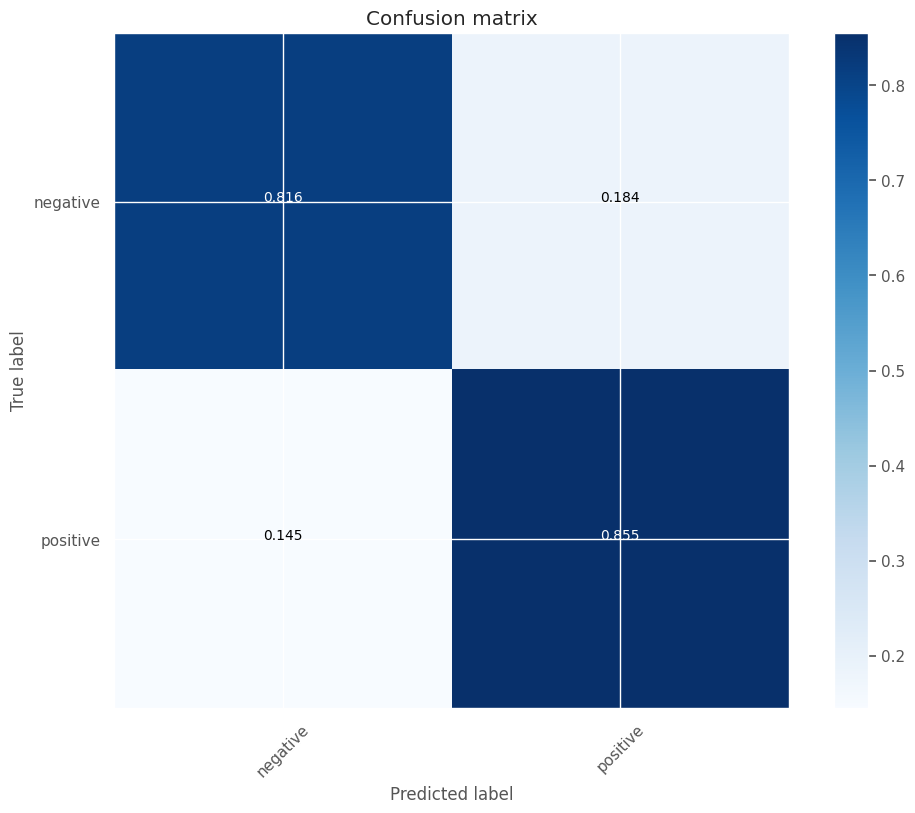

Overall metrics:
{'accuracy': 0.835}


{'accuracy': 0.835}

In [185]:
y_pred = predict_pytorch(model, X_test_tensor)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

In [172]:
class EmbeddingGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dims, num_classes,
                 gru_hidden_dim=128, gru_layers=1, bidirectional=True, dropout=0.5,
                 pretrained_embeddings=None):
        super(EmbeddingGRUClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Cargar los embedding pre entrenados si se pasan
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
            self.embedding.weight.data[0] = 0

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=gru_hidden_dim,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout
        )
        
        gru_output_dim = gru_hidden_dim * 2 if bidirectional else gru_hidden_dim
        
        # MLP
        # Como anteriormente, Lineal, Relu, Dropout
        layers = []
        input_dim = gru_output_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, num_classes))
        self.mlp = nn.Sequential(*layers)
    
    def forward(self, x):
        # Input [B, S]
        embedded = self.embedding(x)
        # Embedded [B, S, E]
        gru_out, _ = self.gru(embedded)    # [B, S, gru_output_dim]
        pooled, _ = gru_out.max(dim=1)     # [B, gru_output_dim]
        output = self.mlp(pooled)          # [B, num_classes]
        return output

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 4188200, shape: [41882, 100]
Name: gru.weight_ih_l0, num params: 38400, shape: [384, 100]
Name: gru.weight_hh_l0, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l0, num params: 384, shape: [384]
Name: gru.bias_hh_l0, num params: 384, shape: [384]
Name: gru.weight_ih_l0_reverse, num params: 38400, shape: [384, 100]
Name: gru.weight_hh_l0_reverse, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l0_reverse, num params: 384, shape: [384]
Name: gru.bias_hh_l0_reverse, num params: 384, shape: [384]
Name: gru.weight_ih_l1, num params: 98304, shape: [384, 256]
Name: gru.weight_hh_l1, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l1, num params: 384, shape: [384]
Name: gru.bias_hh_l1, num params: 384, shape: [384]
Name: gru.weight_ih_l1_reverse, num params: 98304, shape: [384, 25

Epoch 1/80:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 200/200 [00:01<00:00, 186.67it/s]


Epoch 1/80:
Train Loss: 0.6885146772861481, Train Acc: 0.55328125
Val Loss: 0.6651546430587768, Val Acc: 0.71125



Epoch 2/80: 100%|██████████| 200/200 [00:01<00:00, 185.86it/s]


...

Epoch 10/80:
Train Loss: 0.21624330062419175, Train Acc: 0.92046875
Val Loss: 0.36923486560583113, Val Acc: 0.8525



Epoch 11/80: 100%|██████████| 200/200 [00:01<00:00, 185.63it/s]


Epoch 11/80:
Train Loss: 0.1874446054920554, Train Acc: 0.934375
Val Loss: 0.3792022341489792, Val Acc: 0.846875



Epoch 12/80: 100%|██████████| 200/200 [00:01<00:00, 186.21it/s]


Epoch 12/80:
Train Loss: 0.17330319198779762, Train Acc: 0.94109375
Val Loss: 0.3749465189874172, Val Acc: 0.855

Early stopping at epoch 12 (no improvement in 5 epochs)


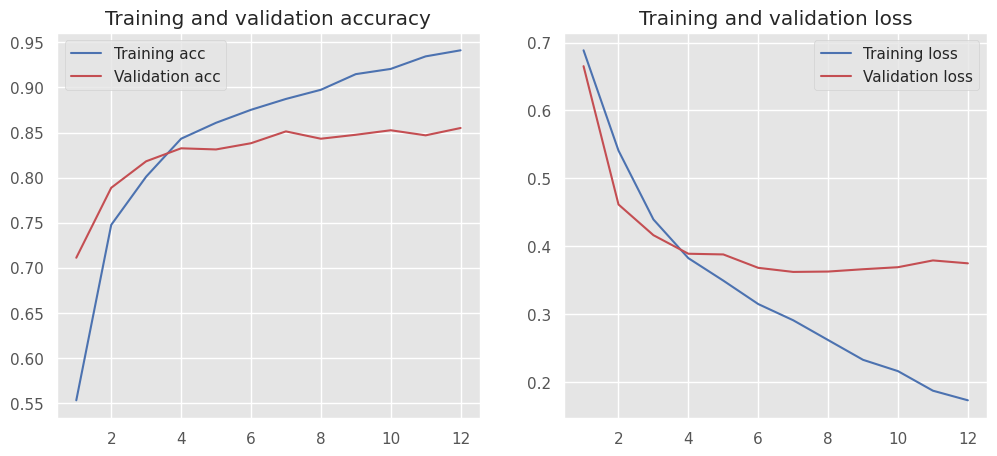

In [173]:
glove_dim = 100

model = EmbeddingGRUClassifier(vocab_size=vocab_size,
    embedding_dim=glove_dim,
    hidden_dims=[128, 64],
    num_classes=num_classes,
    gru_hidden_dim=128,
    gru_layers=2,
    bidirectional=True,
    pretrained_embeddings=embedding_matrix,
    dropout=0.3)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

print_model_params(model)

# Mantenemos batch con longitudes fijas 300
model, history = train_and_evaluate(
    model, 
    train_dataset, 
    valid_dataset,
    criterion,
    optimizer,
    num_epochs=80,
    patience=5
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.86      0.81      0.84      1025
    positive       0.82      0.86      0.84       975

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000

Confusion matrix: 
Confusion matrix, without normalization


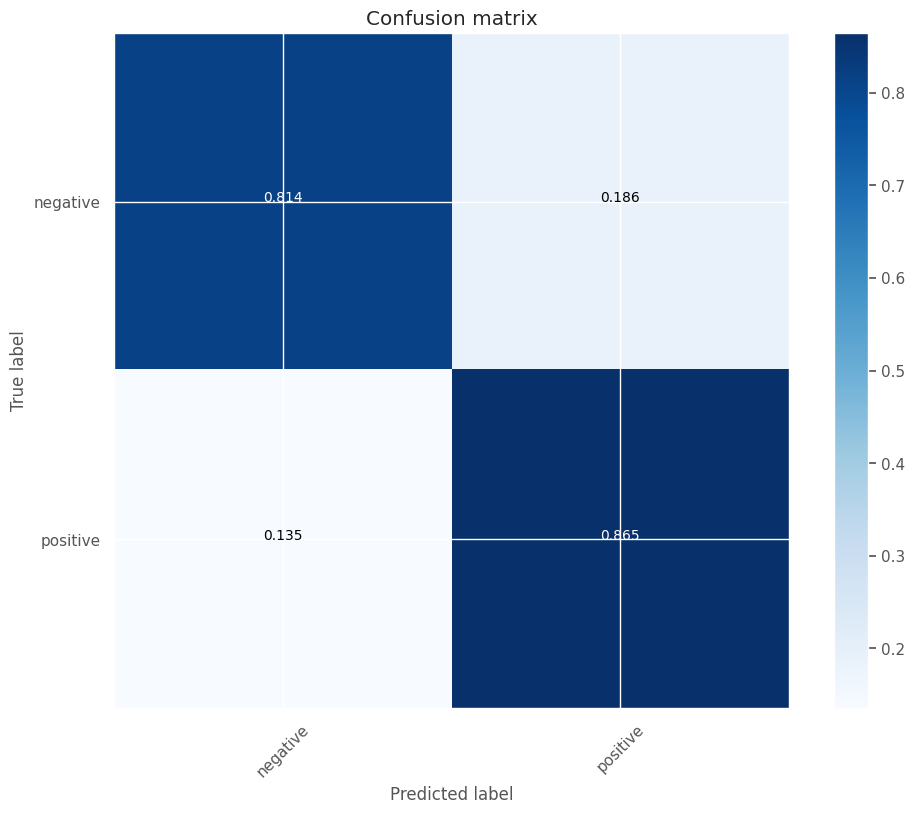

Overall metrics:
{'accuracy': 0.8385}


{'accuracy': 0.8385}

In [174]:
y_pred = predict_pytorch(model, X_test_tensor)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

## ID=11 GRU - DB - Pretrained WE

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 4188200, shape: [41882, 100]
Name: gru.weight_ih_l0, num params: 38400, shape: [384, 100]
Name: gru.weight_hh_l0, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l0, num params: 384, shape: [384]
Name: gru.bias_hh_l0, num params: 384, shape: [384]
Name: gru.weight_ih_l0_reverse, num params: 38400, shape: [384, 100]
Name: gru.weight_hh_l0_reverse, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l0_reverse, num params: 384, shape: [384]
Name: gru.bias_hh_l0_reverse, num params: 384, shape: [384]
Name: gru.weight_ih_l1, num params: 98304, shape: [384, 256]
Name: gru.weight_hh_l1, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l1, num params: 384, shape: [384]
Name: gru.bias_hh_l1, num params: 384, shape: [384]
Name: gru.weight_ih_l1_reverse, num params: 98304, shape: [384, 25

Epoch 1/80:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 400/400 [00:01<00:00, 223.01it/s]


Epoch 1/80:
Train Loss: 0.6518131452798843, Train Acc: 0.61453125
Val Loss: 0.5126685473322868, Val Acc: 0.7575



Epoch 2/80: 100%|██████████| 400/400 [00:01<00:00, 221.04it/s]


...

Epoch 11/80:
Train Loss: 0.11857906488119624, Train Acc: 0.96578125
Val Loss: 0.41293110257945953, Val Acc: 0.85625



Epoch 12/80: 100%|██████████| 400/400 [00:01<00:00, 222.15it/s]


Epoch 12/80:
Train Loss: 0.10016376686457079, Train Acc: 0.97
Val Loss: 0.45135888634249566, Val Acc: 0.853125



Epoch 13/80: 100%|██████████| 400/400 [00:01<00:00, 222.61it/s]


Epoch 13/80:
Train Loss: 0.08328795335604809, Train Acc: 0.97578125
Val Loss: 0.4420461562462151, Val Acc: 0.861875

Early stopping at epoch 13 (no improvement in 5 epochs)


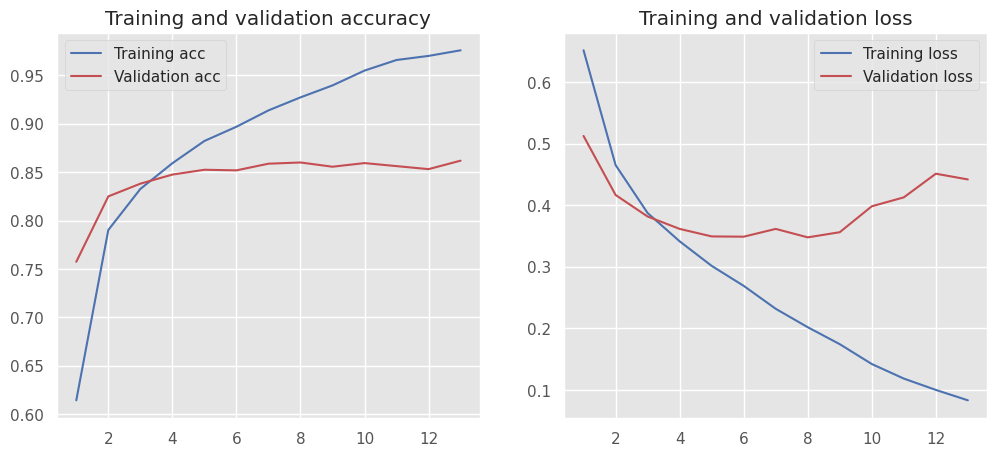

In [175]:
glove_dim = 100

model = EmbeddingGRUClassifier(vocab_size=vocab_size,
    embedding_dim=glove_dim,
    hidden_dims=[128, 64],
    num_classes=num_classes,
    gru_hidden_dim=128,
    gru_layers=2,
    bidirectional=True,
    pretrained_embeddings=embedding_matrix,
    dropout=0.3)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

print_model_params(model)

# Mantenemos batch con longitudes fijas 300
model, history = train_and_evaluate(
    model, 
    train_text_dataset, 
    valid_text_dataset,
    criterion,
    optimizer,
    num_epochs=80,
    patience=5,
    collate_fn=dynamic_batch_fn,
    batch_size=16
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.88      0.79      0.83      1025
    positive       0.80      0.89      0.84       975

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000

Confusion matrix: 
Confusion matrix, without normalization


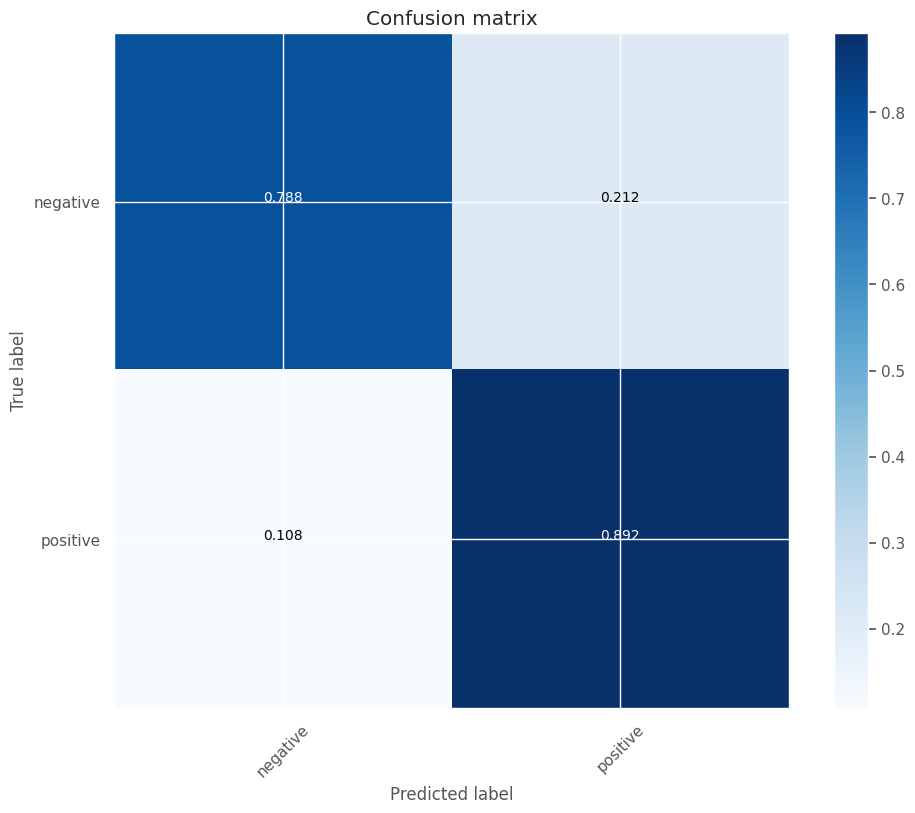

Overall metrics:
{'accuracy': 0.839}


{'accuracy': 0.839}

In [176]:
y_pred = predict_text_pytorch(model, test_text_dataset, batch_size=16, collate_fn=dynamic_batch_fn)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

## ID=12 GRU - DB - Packing - Pretrained WE

In [177]:
class EmbeddingGRUClassifierPack(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dims, num_classes,
                 gru_hidden_dim=128, gru_layers=1, bidirectional=True, dropout=0.5,
                 pretrained_embeddings=None):
        super(EmbeddingGRUClassifierPack, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Cargar los embedding pre entrenados si se pasan
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
            self.embedding.weight.data[0] = 0

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=gru_hidden_dim,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout
        )

        gru_output_dim = gru_hidden_dim * 2 if bidirectional else gru_hidden_dim

        # MLP
        # Como anteriormente, Lineal, Relu, Dropout
        layers = []
        input_dim = gru_output_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x, lengths):
        # Input [B, S]
        embedded = self.embedding(x)
        # Embedded [B, S, E]
        packed = pack_padded_sequence(embedded, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        packed_out, _ = self.gru(packed)
        gru_out, _ = pad_packed_sequence(packed_out, batch_first=True)  # [B, S, gru_output_dim]
        pooled, _ = gru_out.max(dim=1)     # [B, gru_output_dim]
        output = self.mlp(pooled)          # [B, num_classes]
        return output

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 4188200, shape: [41882, 100]
Name: gru.weight_ih_l0, num params: 38400, shape: [384, 100]
Name: gru.weight_hh_l0, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l0, num params: 384, shape: [384]
Name: gru.bias_hh_l0, num params: 384, shape: [384]
Name: gru.weight_ih_l0_reverse, num params: 38400, shape: [384, 100]
Name: gru.weight_hh_l0_reverse, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l0_reverse, num params: 384, shape: [384]
Name: gru.bias_hh_l0_reverse, num params: 384, shape: [384]
Name: gru.weight_ih_l1, num params: 98304, shape: [384, 256]
Name: gru.weight_hh_l1, num params: 49152, shape: [384, 128]
Name: gru.bias_ih_l1, num params: 384, shape: [384]
Name: gru.bias_hh_l1, num params: 384, shape: [384]
Name: gru.weight_ih_l1_reverse, num params: 98304, shape: [384, 25

Epoch 1/80:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 400/400 [00:07<00:00, 51.15it/s]


Epoch 1/80:
Train Loss: 0.6610877459496259, Train Acc: 0.5846875
Val Loss: 0.5187731322646141, Val Acc: 0.750625



Epoch 2/80: 100%|██████████| 400/400 [00:07<00:00, 52.40it/s]


...

Epoch 9/80:
Train Loss: 0.18115375323221086, Train Acc: 0.938125
Val Loss: 0.3862167366221547, Val Acc: 0.850625



Epoch 10/80: 100%|██████████| 400/400 [00:07<00:00, 52.79it/s]


Epoch 10/80:
Train Loss: 0.14697325171669945, Train Acc: 0.95234375
Val Loss: 0.42746685417369007, Val Acc: 0.84875



Epoch 11/80: 100%|██████████| 400/400 [00:07<00:00, 52.96it/s]


Epoch 11/80:
Train Loss: 0.116532108054962, Train Acc: 0.96625
Val Loss: 0.4205824660602957, Val Acc: 0.855

Early stopping at epoch 11 (no improvement in 5 epochs)


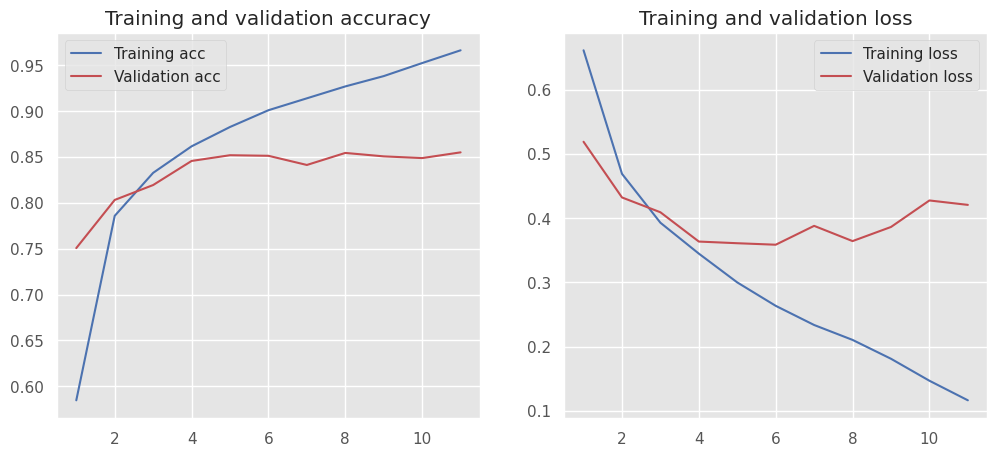

In [179]:
glove_dim = 100

model = EmbeddingGRUClassifierPack(vocab_size=vocab_size,
    embedding_dim=glove_dim,
    hidden_dims=[128, 64],
    num_classes=num_classes,
    gru_hidden_dim=128,
    gru_layers=2,
    bidirectional=True,
    pretrained_embeddings=embedding_matrix,
    dropout=0.3)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

print_model_params(model)

# Mantenemos batch con longitudes fijas 300
model, history = train_and_evaluate(
    model, 
    train_text_dataset, 
    valid_text_dataset,
    criterion,
    optimizer,
    num_epochs=80,
    patience=5,
    collate_fn=packing_collate_fn,
    batch_size=16,
    pass_lengths=True
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.86      0.84      0.85      1025
    positive       0.84      0.86      0.85       975

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion matrix: 
Confusion matrix, without normalization


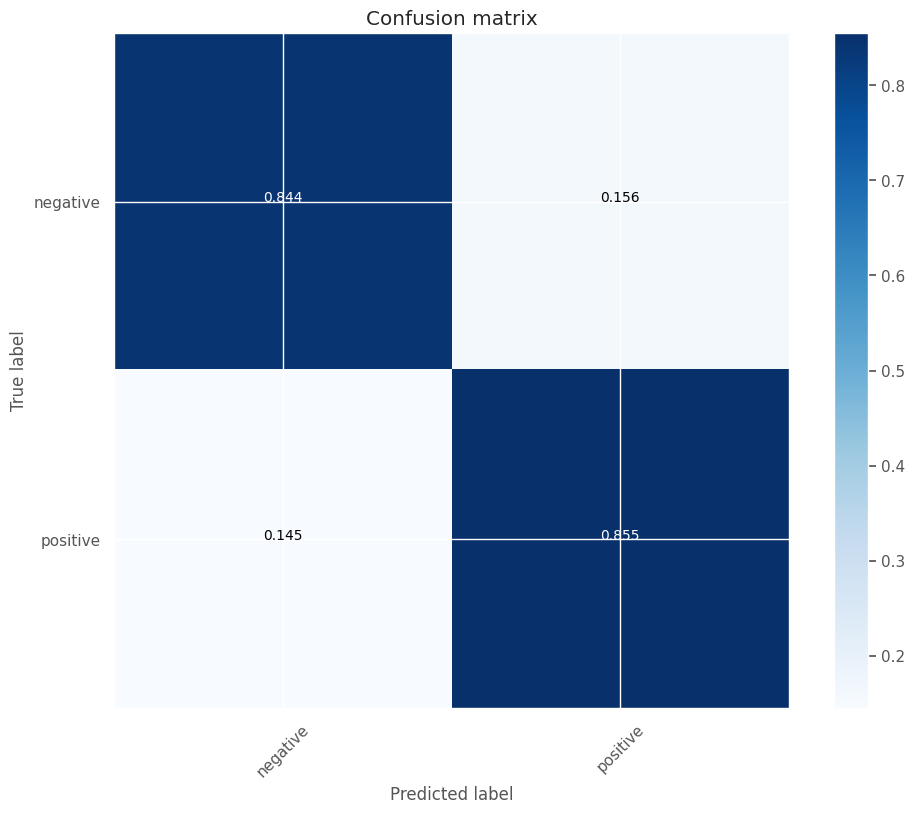

Overall metrics:
{'accuracy': 0.8495}


{'accuracy': 0.8495}

In [180]:
y_pred = predict_text_pytorch(model, test_text_dataset, batch_size=16, collate_fn=packing_collate_fn, pass_lengths=True)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

## ID=13 GRU - DB - Packing - Pretrained WE - Lower Capacity

Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 4188200, shape: [41882, 100]
Name: gru.weight_ih_l0, num params: 19200, shape: [192, 100]
Name: gru.weight_hh_l0, num params: 12288, shape: [192, 64]
Name: gru.bias_ih_l0, num params: 192, shape: [192]
Name: gru.bias_hh_l0, num params: 192, shape: [192]
Name: gru.weight_ih_l0_reverse, num params: 19200, shape: [192, 100]
Name: gru.weight_hh_l0_reverse, num params: 12288, shape: [192, 64]
Name: gru.bias_ih_l0_reverse, num params: 192, shape: [192]
Name: gru.bias_hh_l0_reverse, num params: 192, shape: [192]
Name: mlp.0.weight, num params: 8192, shape: [64, 128]
Name: mlp.0.bias, num params: 64, shape: [64]
Name: mlp.3.weight, num params: 2048, shape: [32, 64]
Name: mlp.3.bias, num params: 32, shape: [32]
Name: mlp.6.weight, num params: 64, shape: [2, 32]
Name: mlp.6.bias, num params: 2, shape: [2

Epoch 1/80:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 1/80: 100%|██████████| 400/400 [00:04<00:00, 85.19it/s]


Epoch 1/80:
Train Loss: 0.6923696438968182, Train Acc: 0.52046875
Val Loss: 0.6879456442594528, Val Acc: 0.54875



Epoch 2/80: 100%|██████████| 400/400 [00:04<00:00, 82.40it/s]


...

Epoch 10/80:
Train Loss: 0.19638991663232447, Train Acc: 0.93390625
Val Loss: 0.3628760477527976, Val Acc: 0.851875



Epoch 11/80: 100%|██████████| 400/400 [00:04<00:00, 82.78it/s]


Epoch 11/80:
Train Loss: 0.1644899815460667, Train Acc: 0.94375
Val Loss: 0.38463078750297425, Val Acc: 0.8525



Epoch 12/80: 100%|██████████| 400/400 [00:04<00:00, 82.86it/s]


Epoch 12/80:
Train Loss: 0.14230198588222265, Train Acc: 0.95296875
Val Loss: 0.39767897005192937, Val Acc: 0.8525

Early stopping at epoch 12 (no improvement in 5 epochs)


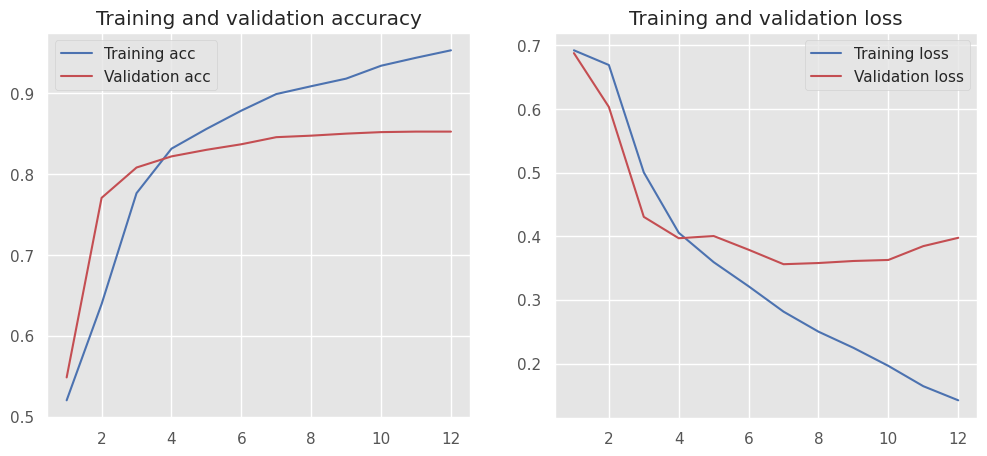

In [181]:
glove_dim = 100

model = EmbeddingGRUClassifierPack(vocab_size=vocab_size,
    embedding_dim=glove_dim,
    hidden_dims=[64, 32],
    num_classes=num_classes,
    gru_hidden_dim=64,
    gru_layers=1,
    bidirectional=True,
    pretrained_embeddings=embedding_matrix,
    dropout=0.3)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

print_model_params(model)

# Mantenemos batch con longitudes fijas 300
model, history = train_and_evaluate(
    model, 
    train_text_dataset, 
    valid_text_dataset,
    criterion,
    optimizer,
    num_epochs=80,
    patience=5,
    collate_fn=packing_collate_fn,
    batch_size=16,
    pass_lengths=True
)
plot_history(history)

Tamaño de y_test (etiquetas): (2000, 1)
Tamaño de y_pred (predicciones): (2000,)
Classification report: 
              precision    recall  f1-score   support

    negative       0.86      0.86      0.86      1025
    positive       0.85      0.85      0.85       975

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion matrix: 
Confusion matrix, without normalization


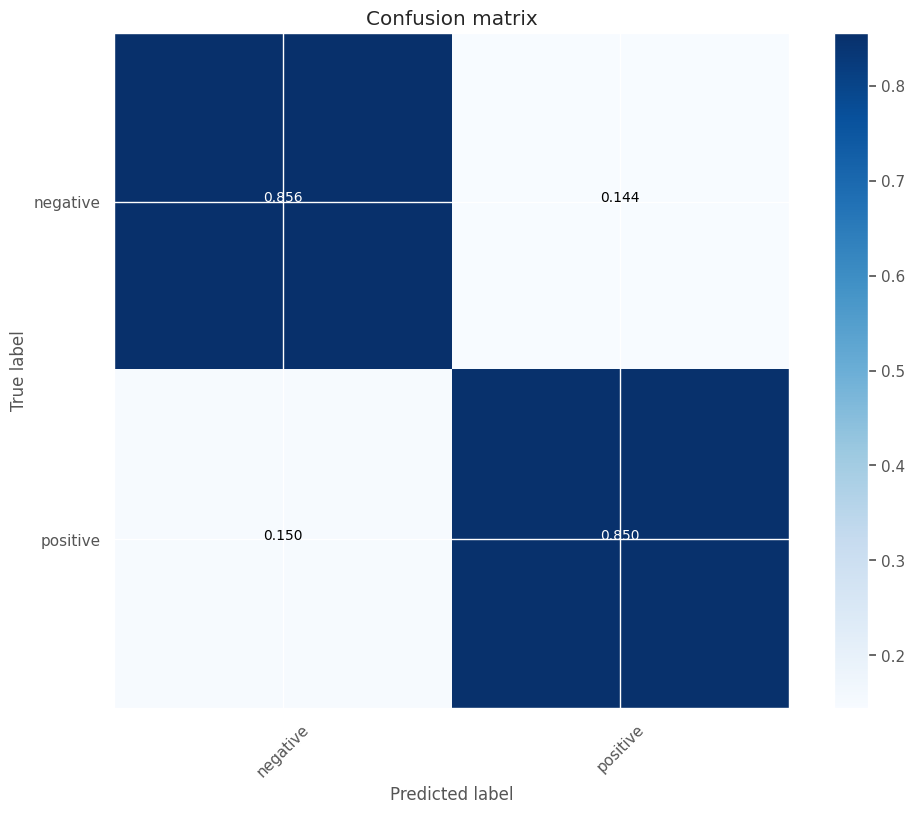

Overall metrics:
{'accuracy': 0.853}


{'accuracy': 0.853}

In [182]:
y_pred = predict_text_pytorch(model, test_text_dataset, batch_size=16, collate_fn=packing_collate_fn, pass_lengths=True)
y_pred_labels = le.inverse_transform(y_pred)

compute_and_show_metrics(y_test, y_pred_labels, target_labels=target_labels)

# Exploración de capacidad

A continuación voy a definir unos parámetros para comparar diferences tamaños de modelo.
Espero que este experimento sirva para ver qué pasa cuando un modelo es pequeño y que pasa cuando un modelo tiene muchos parámetros.

In [46]:
configs = [
    {"embedding_dim": 10, "hidden_dims": [8],       "lstm_hidden_dim": 8,  "lstm_layers": 1},
    {"embedding_dim": 25, "hidden_dims": [16],       "lstm_hidden_dim": 16,  "lstm_layers": 1},
    {"embedding_dim": 50, "hidden_dims": [32],       "lstm_hidden_dim": 32,  "lstm_layers": 1},
    {"embedding_dim": 75, "hidden_dims": [32],       "lstm_hidden_dim": 32,  "lstm_layers": 1},
    {"embedding_dim": 100, "hidden_dims": [64],       "lstm_hidden_dim": 64,  "lstm_layers": 1},
    {"embedding_dim": 200, "hidden_dims": [128, 64],  "lstm_hidden_dim": 128, "lstm_layers": 2},
    {"embedding_dim": 200, "hidden_dims": [128, 64],  "lstm_hidden_dim": 128, "lstm_layers": 2},
]

-----------------
Training: emb=10, lstm_h=8, lstm_l=1, mlp=[8]
-----------------
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 418820, shape: [41882, 10]
Name: lstm.weight_ih_l0, num params: 320, shape: [32, 10]
Name: lstm.weight_hh_l0, num params: 256, shape: [32, 8]
Name: lstm.bias_ih_l0, num params: 32, shape: [32]
Name: lstm.bias_hh_l0, num params: 32, shape: [32]
Name: lstm.weight_ih_l0_reverse, num params: 320, shape: [32, 10]
Name: lstm.weight_hh_l0_reverse, num params: 256, shape: [32, 8]
Name: lstm.bias_ih_l0_reverse, num params: 32, shape: [32]
Name: lstm.bias_hh_l0_reverse, num params: 32, shape: [32]
Name: mlp.0.weight, num params: 128, shape: [8, 16]
Name: mlp.0.bias, num params: 8, shape: [8]
Name: mlp.3.weight, num params: 16, shape: [2, 8]
Name: mlp.3.bias, num params: 2, shape: [2]
Total Parameters: 420254
Trainable Param

Epoch 1/80:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 80/80: 100%|██████████| 200/200 [00:00<00:00, 457.13it/s]


-----------------
Training: emb=25, lstm_h=16, lstm_l=1, mlp=[16]
-----------------
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 1047050, shape: [41882, 25]
Name: lstm.weight_ih_l0, num params: 1600, shape: [64, 25]
Name: lstm.weight_hh_l0, num params: 1024, shape: [64, 16]
Name: lstm.bias_ih_l0, num params: 64, shape: [64]
Name: lstm.bias_hh_l0, num params: 64, shape: [64]
Name: lstm.weight_ih_l0_reverse, num params: 1600, shape: [64, 25]
Name: lstm.weight_hh_l0_reverse, num params: 1024, shape: [64, 16]
Name: lstm.bias_ih_l0_reverse, num params: 64, shape: [64]
Name: lstm.bias_hh_l0_reverse, num params: 64, shape: [64]
Name: mlp.0.weight, num params: 512, shape: [16, 32]
Name: mlp.0.bias, num params: 16, shape: [16]
Name: mlp.3.weight, num params: 32, shape: [2, 16]
Name: mlp.3.bias, num params: 2, shape: [2]
Total Parameters: 1053116
T

Epoch 57/80: 100%|██████████| 200/200 [00:00<00:00, 436.04it/s]


...

Early stopping at epoch 23 (no improvement in 5 epochs)
-----------------
Training: emb=200, lstm_h=128, lstm_l=2, mlp=[128, 64]
-----------------
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 8376400, shape: [41882, 200]
Name: lstm.weight_ih_l0, num params: 102400, shape: [512, 200]
Name: lstm.weight_hh_l0, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0, num params: 512, shape: [512]
Name: lstm.bias_hh_l0, num params: 512, shape: [512]
Name: lstm.weight_ih_l0_reverse, num params: 102400, shape: [512, 200]
Name: lstm.weight_hh_l0_reverse, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0_reverse, num params: 512, shape: [512]
Name: lstm.bias_hh_l0_reverse, num params: 512, shape: [512]
Name: lstm.weight_ih_l1, num params: 131072, shape: [512, 256]
Name: lstm.weight_hh_l1, num params: 65536, shape: [512, 128]
Name: lstm

Epoch 12/80: 100%|██████████| 200/200 [00:01<00:00, 105.00it/s]


Early stopping at epoch 12 (no improvement in 5 epochs)
-----------------
Training: emb=200, lstm_h=128, lstm_l=2, mlp=[128, 64]
-----------------
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
Name: embedding.weight, num params: 8376400, shape: [41882, 200]
Name: lstm.weight_ih_l0, num params: 102400, shape: [512, 200]
Name: lstm.weight_hh_l0, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0, num params: 512, shape: [512]
Name: lstm.bias_hh_l0, num params: 512, shape: [512]
Name: lstm.weight_ih_l0_reverse, num params: 102400, shape: [512, 200]
Name: lstm.weight_hh_l0_reverse, num params: 65536, shape: [512, 128]
Name: lstm.bias_ih_l0_reverse, num params: 512, shape: [512]
Name: lstm.bias_hh_l0_reverse, num params: 512, shape: [512]
Name: lstm.weight_ih_l1, num params: 131072, shape: [512, 256]
Name: lstm.weight_hh_l1, num params: 65536, shape: [512, 128]
Name: lstm

Epoch 11/80: 100%|██████████| 200/200 [00:01<00:00, 104.55it/s]


Early stopping at epoch 11 (no improvement in 5 epochs)


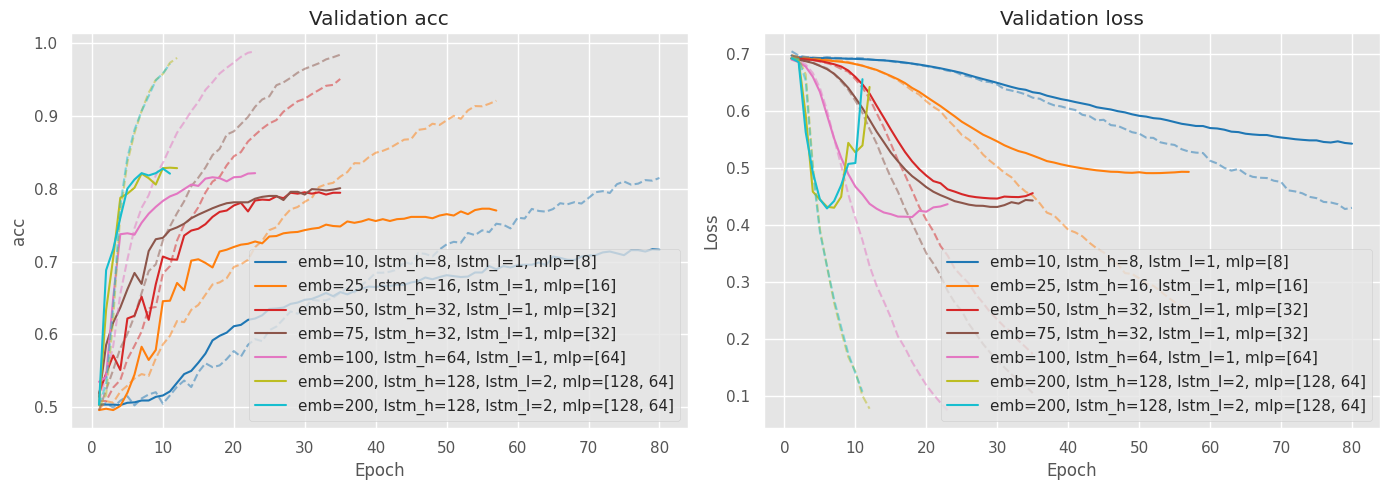

In [47]:
histories = []
names = []
for cfg in configs:
    name = f"emb={cfg['embedding_dim']}, lstm_h={cfg['lstm_hidden_dim']}, lstm_l={cfg['lstm_layers']}, mlp={cfg['hidden_dims']}"
    print(f"-----------------")
    print(f"Training: {name}")
    print(f"-----------------")
    model = EmbeddingLSTMClassifier(
        vocab_size=vocab_size,
        embedding_dim=cfg["embedding_dim"],
        hidden_dims=cfg["hidden_dims"],
        num_classes=num_classes,
        lstm_hidden_dim=cfg["lstm_hidden_dim"],
        lstm_layers=cfg["lstm_layers"],
        bidirectional=True,
        dropout=0.5
    )
    print_model_params(model)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.0001)
    model, history = train_and_evaluate(
        model,
        train_text_dataset,
        valid_text_dataset,
        criterion,
        optimizer,
        num_epochs=80,
        patience=5,
        collate_fn=dynamic_batch_fn,
        batch_size=32,
        verbose=False
    )
    histories.append(history)
    names.append(name)

plot_histories(histories, names)

Se puede ver que un modelo con pocos parámetros (azul oscuro):
- emb=10, lstm_h=8, lstm_l=1, mlp=8, número de parámetros: **420254**
  No consigue reducir lo suficiente las pérdidas.

Un modelo con un gran número de parámetros como:
- emb=200, lstm_h=128, lstm_l=2, mlp=[128, 64] hace overfitting muy rápidamente. Número de parámetros: **9150866**
  Se ve en la curva acul clara que validation loss empieza a aumentar
  en la epoch 7, y train loss (linea a rayas), siguie disminuyendo mucho.

El equilibrio en este sweep se encuentra en los parámetros:
- emb=100, lstm_h=64, lstm_l=1, mlp=64. Número de parámetros: **4281578**
  Con early stopping se consigue parar antes de que haya overfitting.

En todos los experimentos de esta práctica hemos mantenido el early stopping, el cual para antes de "detectar" un overfitting.
Pienso que otra solución para evitar el overfitting es aumentar el número de muestras de entrenamiento.

# Resumen y tabla de resultados

Aquí muestro una tabla con resultados:

| Experimento | Accuracy | Parámetros |
|--------|----------|------------|
| ID=4 WE + LSTM Unidireccional | 81.65% | 8702354 |
| ID=5 WE + LSTM Bidireccional | 83.45% | 9150866 |
| ID=7 WE + GRU Stacked | 81.1% | 8967570 |
| ID=8 WE + LSTM Bidireccional Dynamic Batching | 82.0% | 9150866 |
| ID=9 LSTM Bidireccional - DB - Packing | 82.95% | 9150866 |
| ID=10 LSTM - Bidireccional - PreTrained WE | 83.5% | 4860266 |
| ID=11 GRU - DB - Pretrained WE | 83.9% | 4702570 |
| ID=12 GRU - DB - Packing - Pretrained WE | 84.95% | 4702570 |
| ID=13 GRU - DB - Packing - Pretrained WE - Lower Capacity | 85.3% | 4262346 |

Durante la primera exploración vimos que se obtenia una accuracy algo mejor utilizando una LSTM **Bidireccional** que con una Unidireccional.

No se ha notado una diferencia al usar 2 **GRU's apiladas**.

No hemos conseguido entrenar correctamente una **RNN** con estas secuencias. Su entrenamiento no conseguia aprender (reducir train loss) y cuando se ha reducido la longitud de las secuencias, se hacía **demasiado overfitting**.

Después se ha explorado la técnica del **batch de tamaño de secuencia dinámico** y no se han apreciado mejorias.

Se ha apreciado algo más de mejoría en la accuracy al añadir **Word Embeddings Pre entrenados**. Con esta matriz de embeddings preentrenados, batch dinámico y packing
se ha alcanzado un 84.95% que después se ha mejorado **reduciendo la capacidad** del modelo, para tratar de reducir el overfitting y mejorar la generalización y
se ha obtenido un **85.3%** de accuracy.

Sobre el número de parámetros se ha visto que en los primeros experimentos, la mayor parte de los parámetros realmente se encuentra en la matriz de embeddings.
Se puede ver la reducción entre ID=9 y ID=10 porque se ha cambiado de embeddings de 200 a 100 con Glove.
Después, se ha reducido el tamaño de la red recurrente en ID=13 y se ha pasado de 4702570 parámetros a 4262346.

### Técnicas utilizadas para combatir el overfitting:

En resumen, en esta práctica, para tratar de reducir el overfitting y generalizar mejor en los datos de evaluación hemos utilizado:
- **Dropout** en todos los modelos. Con el fin de crear conexiones redundantes. No queremos que una sola neurona sea demasiado importante.
- **Early stopping**: Parar el entrenamiento cuando val loss no mejora. Esto hace generalmente que se pare antes de que haya overfitting.
- **Word Embedding Pre entrenados**: Estos WE pre entrenados es posible que hayan sido entrenados en un dataset más grande y quizá hayan sido capaces de capturar un espacio vectorial denso más apropiado para una tarea de clasificación posterior. Nuestro dataset es probable que sea algo más pequeño.
- **Reducción del número de parámetros del modelo**: Al final, hemos reducido la capacidad del modelo (un modelo más pequeño) y este junto con WE pre entrenados ha sido el que mejor resultado ha dado en evaluación (**85.3%**).

